# Wearables Glove Project - Experimental Results

Reproduz a pipeline do jogo sem o jogar:
1. **Calibracao** - curva piecewise linear identica ao `data_preprocessing.py`
2. **Normalizacao** - aplicar calibracao a dados brutos do raw data script
3. **Analise de tremores** - mesma FFT de `imu_tremor_analysis()` do jogo
4. **Sweep de frequencias** - testar deteccao sem hardware

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [39]:
GAME_CSV    = "recordings/Patient_levelA_20260618_133259.csv"
RAW_CSV     = None   # ex: "adc_data_20260618_100032.csv"
SAMPLE_RATE = 60.0
TREMOR_LOW  = 4.0
TREMOR_HIGH = 7.0

FINGER_RAW_COLS = {
    "Thumb":  "Channel_9",
    "Index":  "Channel_13",
    "Middle": "Channel_5",
    "Ring":   "Channel_6",
    "Pinky":  "Channel_10",
}
IMU_RAW_COLS = ["Channel_15", "Channel_16", "Channel_17"]
COLORS = plt.cm.tab10(range(5))

## 1. Calibracao

In [40]:
def _is_float(s):
    try: float(s); return True
    except: return False

def load_calibration(path):
    calib, names = {}, []
    with open(path) as f:
        for line in f:
            p = [x.strip() for x in line.rstrip("\n").split(",")]
            if p[0] == "#":
                names = [x for x in p[1:] if x and not x.startswith("ch")]
            elif p[0] in ("calib_closed","calib_half","calib_open","calib_span"):
                key = p[0].replace("calib_","")
                vals = [float(x) for x in p[1:] if x and _is_float(x)]
                calib[key] = np.array(vals[:len(names)] if names else vals)
            elif p[0] == "time_s":
                break
    return calib, names

calib, finger_names = load_calibration(GAME_CSV)
if not finger_names: finger_names = list(FINGER_RAW_COLS.keys())
n_fingers = len(finger_names)
spans     = calib["span"]

print(f"Dedos: {finger_names}\n")
print(f'{"Dedo":<10} {"Closed":>12} {"Half":>12} {"Open":>12} {"Span":>12}')
print("-"*52)
for i, nm in enumerate(finger_names):
    print(f"{nm:<10} {calib[\"closed\"][i]:>12.1f} {calib[\"half\"][i]:>12.1f}",
          f"{calib[\"open\"][i]:>12.1f} {calib[\"span\"][i]:>12.1f}")

SyntaxError: unexpected character after line continuation character (940569293.py, line 29)

### 1.1 Funcoes de normalizacao (identicas ao jogo)

In [41]:
# Copia exacta de _piecewise_interp de data_preprocessing.py
def piecewise_interp(v, v_closed, v_half, v_open):
    span_lo = v_half - v_closed
    span_hi = v_open  - v_half
    if (v_closed <= v <= v_half) or (v_half <= v <= v_closed):
        return -1.0 if span_lo == 0 else -1.0 + (v - v_closed) / span_lo
    else:
        return  0.0 if span_hi == 0 else  0.0 + (v - v_half)   / span_hi

def normalize_finger(raw_vals, v_closed, v_half, v_open):
    v_lo = min(v_closed, v_open); v_hi = max(v_closed, v_open)
    clamped = np.clip(np.asarray(raw_vals, float), v_lo, v_hi)
    return np.clip([piecewise_interp(v, v_closed, v_half, v_open) for v in clamped], -1.0, 1.0)

### 1.2 Plot da curva de calibracao + media dos 5 dedos

In [43]:
fig, axes = plt.subplots(1, n_fingers + 1, figsize=(3.5*(n_fingers+1), 4),
                         sharey=True, constrained_layout=True)
fig.suptitle("Curvas de calibracao - piecewise linear (identico ao jogo)", fontsize=13)

curves_norm = []
x_norm = np.linspace(0, 1, 300)  # 0=closed, 0.5=half, 1=open

for i, (ax, name) in enumerate(zip(axes[:-1], finger_names)):
    v_cl = calib["closed"][i]; v_h = calib["half"][i]; v_op = calib["open"][i]
    v_lo, v_hi = min(v_cl, v_op), max(v_cl, v_op)
    v_rng = np.linspace(v_lo, v_hi, 300)
    ap_rng = normalize_finger(v_rng, v_cl, v_h, v_op)

    ax.plot(v_rng, ap_rng, color=COLORS[i], lw=2.5)
    ax.scatter([v_cl, v_h, v_op], [-1, 0, 1], color=COLORS[i], s=80, zorder=5, edgecolors="k", lw=0.8)
    for vx, vy, lbl in zip([v_cl,v_h,v_op],[-1,0,1],["Closed(-1)","Half(0)","Open(+1)"]):
        ax.annotate(lbl, (vx, vy), xytext=(5,0), textcoords="offset points", fontsize=7, color="gray")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_title(name, color=COLORS[i]); ax.set_xlabel("Raw ADC")
    ax.set_ylim(-1.3, 1.3); ax.grid(True, alpha=0.25)

    # curva em eixo normalizado para o painel da media
    v_range_i = v_cl + x_norm * (v_op - v_cl)
    curves_norm.append(normalize_finger(v_range_i, v_cl, v_h, v_op))

axes[0].set_ylabel("Aperture")

ax_m = axes[-1]
for i, nm in enumerate(finger_names):
    ax_m.plot(x_norm, curves_norm[i], color=COLORS[i], lw=1, alpha=0.45, label=nm)
mean_curve = np.average(curves_norm, axis=0, weights=spans)
ax_m.plot(x_norm, mean_curve, color="black", lw=2.5, label="Media (span)")
ax_m.axhline(0, color="gray", lw=0.5, ls="--")
ax_m.set_xlabel("Posicao normalizada\n(0=closed  0.5=half  1=open)")
ax_m.set_title("Media ponderada (span)", fontweight="bold")
ax_m.legend(fontsize=8); ax_m.grid(True, alpha=0.25)

plt.savefig("calibration_curves.png", bbox_inches="tight")
plt.show()

print("\nSpans (maior = sensor mais fiavel):")
for nm, s in zip(finger_names, spans):
    bar = chr(9608) * int(s / max(spans) * 30)
    print(f"  {nm:<8} {s:>10.0f}  {bar}")

NameError: name 'n_fingers' is not defined

## 2. Normalizar dados brutos (do raw data script)

In [44]:
def load_game_data(path):
    with open(path) as f: lines = f.readlines()
    start = next(i for i, l in enumerate(lines) if l.startswith("time_s"))
    return pd.read_csv(path, skiprows=start)

if RAW_CSV is None:
    print("RAW_CSV=None -> a usar dados do CSV do jogo (ja normalizados)")
    df = load_game_data(GAME_CSV)
    print(f"{len(df)} amostras, colunas: {list(df.columns)}")
    t = df["time_s"].values
    apertures = {nm: df[nm].values for nm in finger_names if nm in df.columns}
else:
    df_raw = pd.read_csv(RAW_CSV)
    print(f"CSV bruto: {len(df_raw)} linhas, colunas: {list(df_raw.columns)}")
    t = np.arange(len(df_raw)) / SAMPLE_RATE
    apertures = {}
    for i, nm in enumerate(finger_names):
        col = FINGER_RAW_COLS.get(nm)
        if col not in df_raw.columns: print(f"  AVISO: {col} nao encontrada"); continue
        apertures[nm] = normalize_finger(df_raw[col].values,
            calib["closed"][i], calib["half"][i], calib["open"][i])
        print(f"  {nm}: [{apertures[nm].min():.3f}, {apertures[nm].max():.3f}]")

valid_names = [nm for nm in finger_names if nm in apertures]
arr_ap  = np.array([apertures[nm] for nm in valid_names])
w_ap    = np.array([spans[finger_names.index(nm)] for nm in valid_names])
mean_ap = np.average(arr_ap, axis=0, weights=w_ap)
print(f"\nApertura media: [{mean_ap.min():.3f}, {mean_ap.max():.3f}]")

RAW_CSV=None -> a usar dados do CSV do jogo (ja normalizados)
1205 amostras, colunas: ['time_s', 'Thumb', 'Index', 'Middle', 'Ring', 'Pinky', 'ch15', 'ch16', 'ch17']

Apertura media: [-0.974, 0.977]


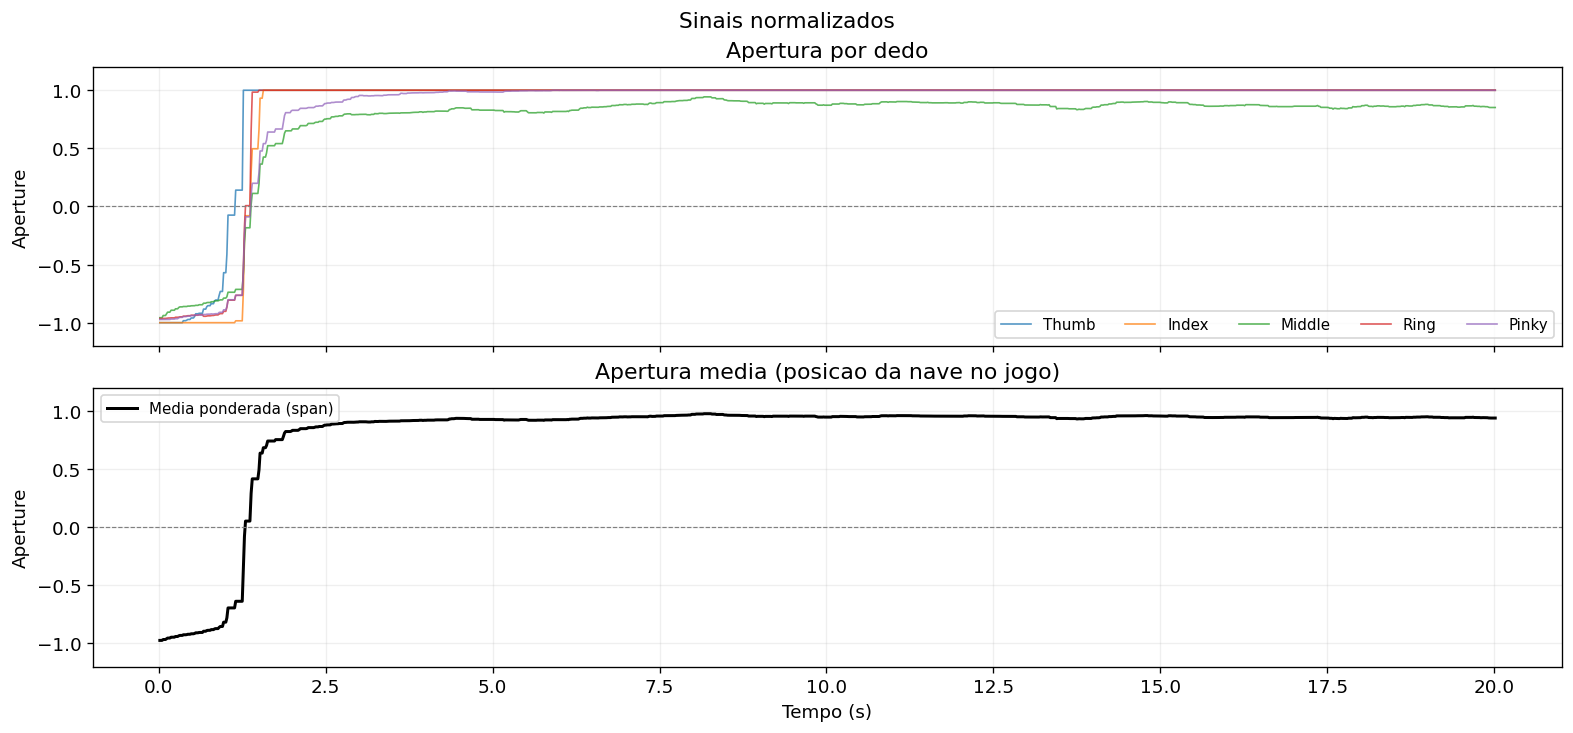

In [45]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
fig.suptitle("Sinais normalizados", fontsize=13)

for i, nm in enumerate(valid_names):
    ax1.plot(t, apertures[nm], color=COLORS[i%5], lw=1, alpha=0.75, label=nm)
ax1.axhline(0, color="gray", ls="--", lw=0.7)
ax1.set_ylabel("Aperture"); ax1.set_ylim(-1.2, 1.2)
ax1.legend(ncol=5, fontsize=9); ax1.grid(True, alpha=0.2)
ax1.set_title("Apertura por dedo")

ax2.plot(t, mean_ap, color="black", lw=1.8, label="Media ponderada (span)")
ax2.axhline(0, color="gray", ls="--", lw=0.7)
ax2.set_xlabel("Tempo (s)"); ax2.set_ylabel("Aperture")
ax2.set_ylim(-1.2, 1.2); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2)
ax2.set_title("Apertura media (posicao da nave no jogo)")

plt.savefig("normalized_signal.png", bbox_inches="tight")
plt.show()

## 3. Analise de tremores IMU (identico ao jogo)

In [48]:
# Copia exacta de imu_tremor_analysis() de game.py
def imu_tremor_analysis(imu_rows, sr=60.0, low=4.0, high=7.0):
    arr = np.array(imu_rows, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 3 or arr.shape[0] < 32:
        return dict(dominant_hz=0.0, band_power=0.0, relative_power_pct=0.0, pct_time_tremor=0.0)
    arr -= arr.mean(axis=0)
    freqs = np.fft.rfftfreq(arr.shape[0], d=1.0/sr)
    power = np.zeros(len(freqs))
    for ch in range(arr.shape[1]): power += np.abs(np.fft.rfft(arr[:,ch]))**2
    mb = (freqs >= low) & (freqs <= high)
    dom  = float(freqs[mb][np.argmax(power[mb])]) if mb.any() and power[mb].max()>0 else 0.0
    bp   = float(power[mb].sum()) if mb.any() else 0.0
    rp   = 100.0*bp/float(power.sum()) if power.sum()>0 else 0.0
    win  = max(16, int(sr)); hop = max(1, win//2)
    wf   = np.fft.rfftfreq(win, d=1.0/sr); wm = (wf>=low)&(wf<=high)
    tw = tot = 0
    for s in range(0, arr.shape[0]-win+1, hop):
        c  = arr[s:s+win]
        wp = np.zeros(len(wf))
        for ch in range(c.shape[1]): wp += np.abs(np.fft.rfft(c[:,ch]-c[:,ch].mean()))**2
        wt = wp.sum(); wb = wp[wm].sum() if wm.any() else 0.0
        if wt > 0 and (wb/wt) > 0.20: tw += 1
        tot += 1
    return dict(dominant_hz=dom, band_power=bp, relative_power_pct=rp,
                pct_time_tremor=100.0*tw/max(1,tot))

def print_tremor(res, label=""):
    print(f"\n--- Tremor {label} ---")
    print(f"  Frequencia dominante (4-7 Hz) : {res['dominant_hz']:.2f} Hz")
    print(f"  Band power total (4-7 Hz)     : {res['band_power']:.1f}")
    print(f"  Relative tremor power         : {res['relative_power_pct']:.1f} %")
    print(f"  % tempo com tremor activo     : {res['pct_time_tremor']:.1f} %")

In [50]:
if RAW_CSV is None:
    df = load_game_data(GAME_CSV)
    imu_cols = [c for c in ["ch15","ch16","ch17"] if c in df.columns]
    if imu_cols:
        imu_data = df[imu_cols].values
        sr_used  = 1.0 / float(np.median(np.diff(df["time_s"].values)))
        print(f"IMU: {imu_data.shape[0]} amostras @ {sr_used:.1f} Hz")
    else:
        print("Sem colunas IMU no CSV â€” usa a seccao 4 para teste sintetico"); imu_data=None; sr_used=SAMPLE_RATE
else:
    df_raw = pd.read_csv(RAW_CSV)
    imu_cols = [c for c in IMU_RAW_COLS if c in df_raw.columns]
    imu_data = df_raw[imu_cols].values if imu_cols else None; sr_used = SAMPLE_RATE

if imu_data is not None and imu_data.shape[1] >= 3:
    res = imu_tremor_analysis(imu_data, sr=sr_used, low=TREMOR_LOW, high=TREMOR_HIGH)
    print_tremor(res, "dados reais")

    arr = imu_data.astype(float); arr -= arr.mean(axis=0)
    ff  = np.fft.rfftfreq(len(arr), d=1.0/sr_used)
    pw  = np.zeros(len(ff))
    for ch in range(arr.shape[1]): pw += np.abs(np.fft.rfft(arr[:,ch]))**2

    fig, ax = plt.subplots(figsize=(11,4), constrained_layout=True)
    ax.semilogy(ff, pw, color="steelblue", lw=1.2, label="Power spectrum (3 eixos)")
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.15, color="red", label=f"{TREMOR_LOW}-{TREMOR_HIGH} Hz")
    if res["dominant_hz"]>0: ax.axvline(res["dominant_hz"], color="red", ls="--", lw=1.5,
                                         label=f"Dom. {res[\"dominant_hz\"]:.2f} Hz")
    ax.set_xlabel("Frequencia (Hz)"); ax.set_ylabel("Power (log)")
    ax.set_title("Espectro IMU - ch15+ch16+ch17 (apos remocao de DC)")
    ax.set_xlim(0, min(30, ff[-1])); ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
    plt.savefig("tremor_spectrum_real.png", bbox_inches="tight"); plt.show()

SyntaxError: unexpected character after line continuation character (2488386075.py, line 28)

## 4. Testar diferentes frequencias de tremor (sem hardware)

In [ ]:
def simulate_imu(freq_hz, duration_s=20.0, amplitude=200, sr=60.0, noise_std=15, dc_offset=500):
    """Sinal IMU sintetico com tremor + DC offset (removido antes da FFT)."""
    N = int(duration_s * sr); t = np.linspace(0, duration_s, N)
    c1 = dc_offset + amplitude*np.sin(2*np.pi*freq_hz*t)         + np.random.normal(0,noise_std,N)
    c2 = dc_offset + amplitude*np.sin(2*np.pi*freq_hz*t+np.pi/4) + np.random.normal(0,noise_std,N)
    c3 = dc_offset + amplitude*np.sin(2*np.pi*freq_hz*t+np.pi/2) + np.random.normal(0,noise_std,N)
    return np.column_stack([c1, c2, c3])

test_freqs = [1.0, 2.0, 3.0, 4.0, 5.0, 5.5, 6.0, 7.0, 8.0, 10.0, 15.0]
results = []
for freq in test_freqs:
    r = imu_tremor_analysis(simulate_imu(freq, sr=SAMPLE_RATE), sr=SAMPLE_RATE, low=TREMOR_LOW, high=TREMOR_HIGH)
    r["input_freq"] = freq; results.append(r)

df_res = pd.DataFrame(results)[["input_freq","dominant_hz","relative_power_pct","pct_time_tremor","band_power"]]
df_res.columns = ["Input (Hz)","Dominant Hz","Rel. power (%)","% time tremor","Band power"]
print(df_res.to_string(index=False, float_format="{:.2f}".format))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
fig.suptitle("Resposta do detector vs frequencia de entrada", fontsize=13)
fi = [r["input_freq"] for r in results]
for ax in axes:
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.2, color="#ffcccc", label="Tremor band")
    ax.set_xlabel("Frequencia de entrada (Hz)"); ax.grid(True, alpha=0.2)

axes[0].plot(fi,[r["relative_power_pct"] for r in results],"o-",color="steelblue",lw=2)
axes[0].set_ylabel("Relative tremor power (%)"); axes[0].set_title("Potencia relativa")
axes[0].legend(fontsize=9)
axes[1].plot(fi,[r["pct_time_tremor"] for r in results],"s-",color="darkorange",lw=2)
axes[1].set_ylabel("% tempo com tremor"); axes[1].set_title("% tempo com tremor activo")
axes[2].plot(fi, fi, "--", color="gray", lw=1, label="Ideal")
axes[2].plot(fi,[r["dominant_hz"] for r in results],"^-",color="green",lw=2,label="Detectado")
axes[2].set_ylabel("Frequencia detectada (Hz)"); axes[2].set_title("Frequencia dominante")
axes[2].legend(fontsize=9)
plt.savefig("tremor_freq_sweep.png", bbox_inches="tight"); plt.show()

In [ ]:
n_cols = 4; n_rows = int(np.ceil(len(test_freqs)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5*n_cols, 3*n_rows), constrained_layout=True)
fig.suptitle("Espectros por frequencia  (vermelho=banda 4-7Hz  verde=freq input)", fontsize=12)
flat = axes.flatten()
for ax, freq, res in zip(flat, test_freqs, results):
    sim = simulate_imu(freq, sr=SAMPLE_RATE)
    arr = sim - sim.mean(axis=0)
    ff  = np.fft.rfftfreq(len(arr), d=1.0/SAMPLE_RATE)
    pw  = np.zeros(len(ff))
    for ch in range(3): pw += np.abs(np.fft.rfft(arr[:,ch]))**2
    ax.semilogy(ff, pw, color="steelblue", lw=1)
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.2, color="red")
    ax.axvline(freq, color="green", ls="--", lw=1.2)
    ax.set_title(f"{freq} Hz -> det: {res[\"dominant_hz\"]:.1f} Hz", fontsize=9)
    ax.set_xlim(0, 20); ax.set_xlabel("Hz", fontsize=8); ax.tick_params(labelsize=7)
for ax in flat[len(test_freqs):]: ax.set_visible(False)
plt.savefig("tremor_spectra_grid.png", bbox_inches="tight"); plt.show()

## TEST 1 — Opening/closing at different speeds (low / med / high)

Calibration **per data**: each channel uses its own min/max within each test.
Does not depend on the game CSV — suitable when sessions were recorded at different times.

- `aperture = +1` -> hand open (minimum ADC of channel)
- `aperture = -1` -> hand closed (maximum ADC of channel)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TEST1_DIR = "RECORDINGS FOR TEST/"
TEST1_FILES = {
    "low" : TEST1_DIR + "test1_low freq.csv",
    "med" : TEST1_DIR + "test1_med freq.csv",
    "high": TEST1_DIR + "test1_high freq.csv",
}
TEST1_COLORS = {"low": "steelblue", "med": "darkorange", "high": "crimson"}

CHANNELS = {
    "Channel_5" : "Middle",
    "Channel_6" : "Ring",
    "Channel_8" : "Index",
    "Channel_9" : "Thumb",
    "Channel_10": "Pinky",
}
CH_COLS  = list(CHANNELS.keys())
CH_NAMES = list(CHANNELS.values())
COLORS5  = plt.cm.tab10(range(5))
MA_WINDOW  = 30
T_START    = 4.0   # start of analysis window (seconds)
T_END      = 23.0  # end of analysis window (seconds)

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0: return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

tests = {}
for label, path in TEST1_FILES.items():
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    t  = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().values

    # 1. Moving average on raw data
    smoothed = {col: moving_average(df[col].values.astype(float), MA_WINDOW)
                for col in CH_COLS if col in df.columns}

    # 2. Analysis window mask
    mask = (t >= T_START) & (t <= T_END)
    print(f"{label}: {mask.sum()} samples in window [{T_START}s, {T_END}s]")

    # 3. Calibration: min/max computed only within the window
    calib_test = {}
    aps = {}
    for col, arr in smoothed.items():
        arr_w = arr[mask]
        vmin, vmax = arr_w.min(), arr_w.max()
        calib_test[col] = (vmin, vmax)
        # Normalize full signal with window limits (may exceed [-1,1] outside window)
        aps[col] = normalize_linear(arr, vmin, vmax)

    # 4. Span-weighted mean (within window)
    avail   = [c for c in CH_COLS if c in aps]
    arr_all = np.array([aps[c] for c in avail])
    spans   = np.array([calib_test[c][1] - calib_test[c][0] for c in avail])
    mean_ap = np.average(arr_all, axis=0, weights=spans)

    tests[label] = dict(df=df, t=t, mask=mask, smoothed=smoothed,
                        aps=aps, mean_ap=mean_ap, calib=calib_test)
    ap_w = mean_ap[mask]
    print(f"  aperture in window [{ap_w.min():.2f}, {ap_w.max():.2f}]\n")

low: 1902 samples in window [4.0s, 23.0s]
  aperture in window [-0.99, 0.94]

med: 1884 samples in window [4.0s, 23.0s]
  aperture in window [-0.92, 0.99]

high: 1896 samples in window [4.0s, 23.0s]
  aperture in window [-0.91, 0.96]



### Calibration curves — 5 channels x 3 tests (15 plots)

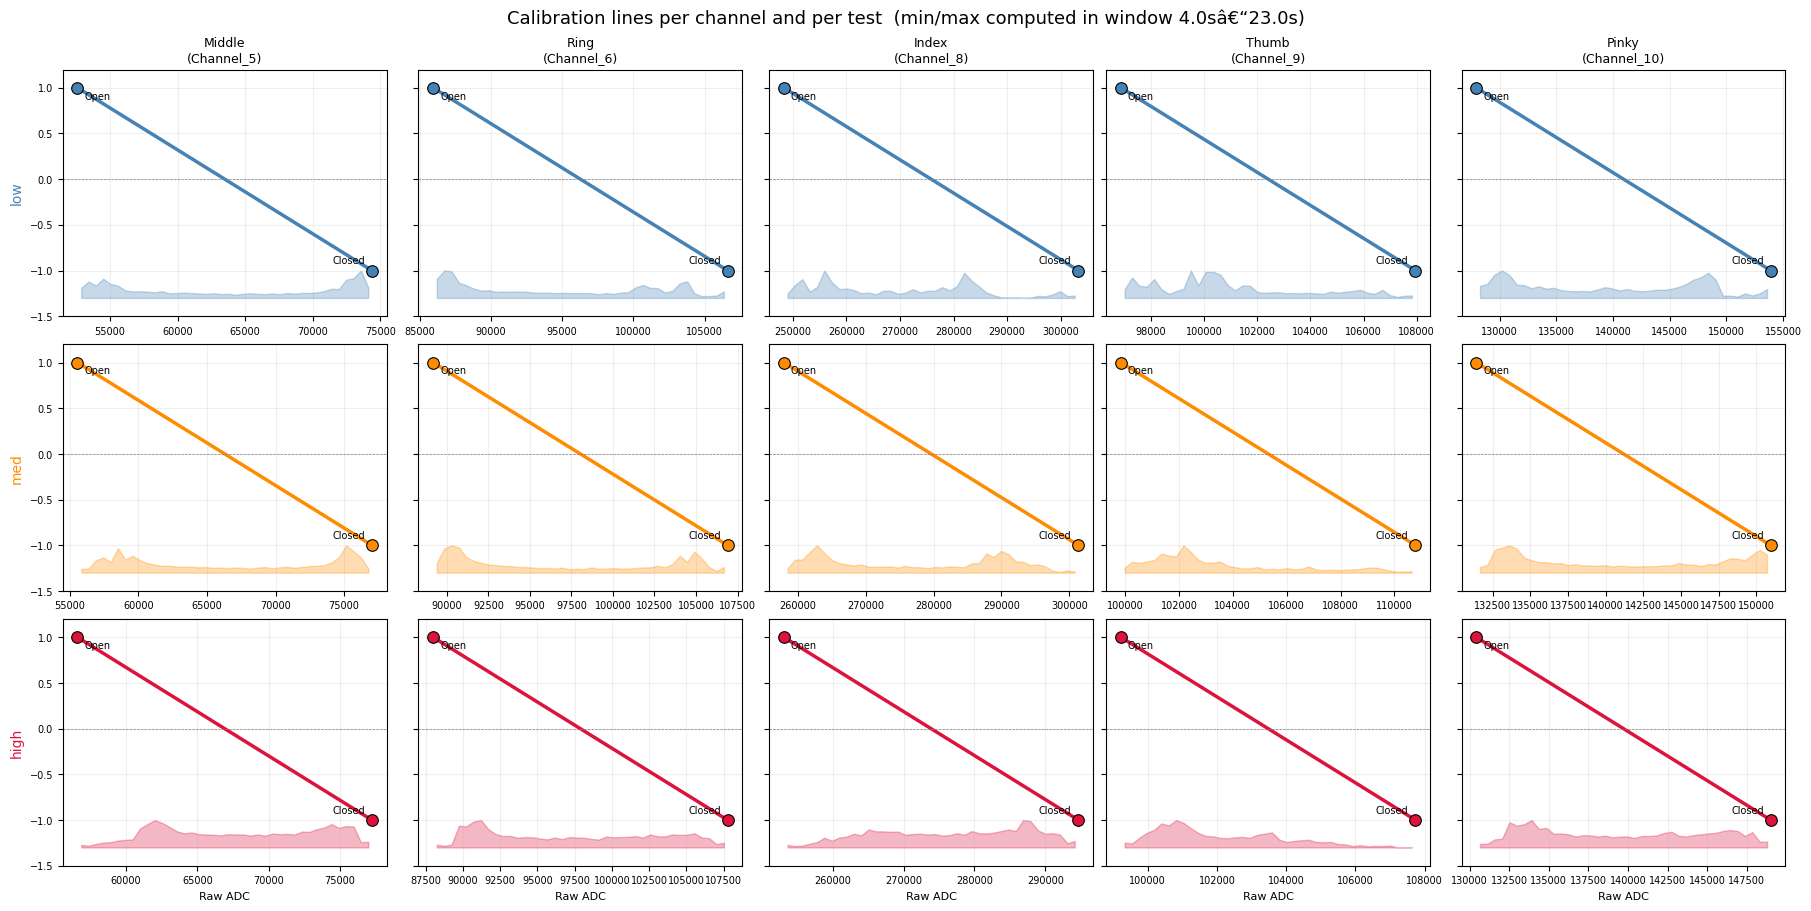

In [32]:
fig, axes = plt.subplots(3, 5, figsize=(18, 9),
                         sharey=True, constrained_layout=True)
fig.suptitle(
    f"Calibration lines per channel and per test  "
    f"(min/max computed in window {T_START}sâ€“{T_END}s)",
    fontsize=13)

for row, (label, td) in enumerate(tests.items()):
    for col_i, (col, nm) in enumerate(CHANNELS.items()):
        ax = axes[row][col_i]
        if col not in td["calib"]:
            ax.set_visible(False); continue
        vmin, vmax = td["calib"][col]

        # Linear calibration line
        v_rng  = np.linspace(vmin, vmax, 200)
        ap_rng = normalize_linear(v_rng, vmin, vmax)
        ax.plot(v_rng, ap_rng, color=TEST1_COLORS[label], lw=2.5)

        # Reference points
        ax.scatter([vmax, vmin], [-1, 1], color=TEST1_COLORS[label],
                   s=70, zorder=5, edgecolors="black", lw=0.8)
        ax.annotate("Closed", (vmax, -1), xytext=(-5, 5),
                    textcoords="offset points", fontsize=7, ha="right")
        ax.annotate("Open",   (vmin,  1), xytext=(5, -8),
                    textcoords="offset points", fontsize=7)

        # Histogram within analysis window only
        raw_w = td["smoothed"][col][td["mask"]]
        hist, edges = np.histogram(raw_w, bins=40, range=(vmin, vmax))
        hist_norm = hist / hist.max() * 0.3
        ax.fill_between((edges[:-1]+edges[1:])/2, -1.3, -1.3+hist_norm,
                        alpha=0.3, color=TEST1_COLORS[label])

        ax.axhline(0, color="gray", lw=0.5, ls="--")
        ax.set_ylim(-1.5, 1.2)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)

        if row == 0: ax.set_title(f"{nm}\n({col})", fontsize=9)
        if col_i == 0: ax.set_ylabel(f"{label}", fontsize=10, color=TEST1_COLORS[label])
        if row == 2: ax.set_xlabel("Raw ADC", fontsize=8)

plt.savefig("test1_calibration_curves.png", bbox_inches="tight")
plt.show()

### Mean aperture over time — one plot per test

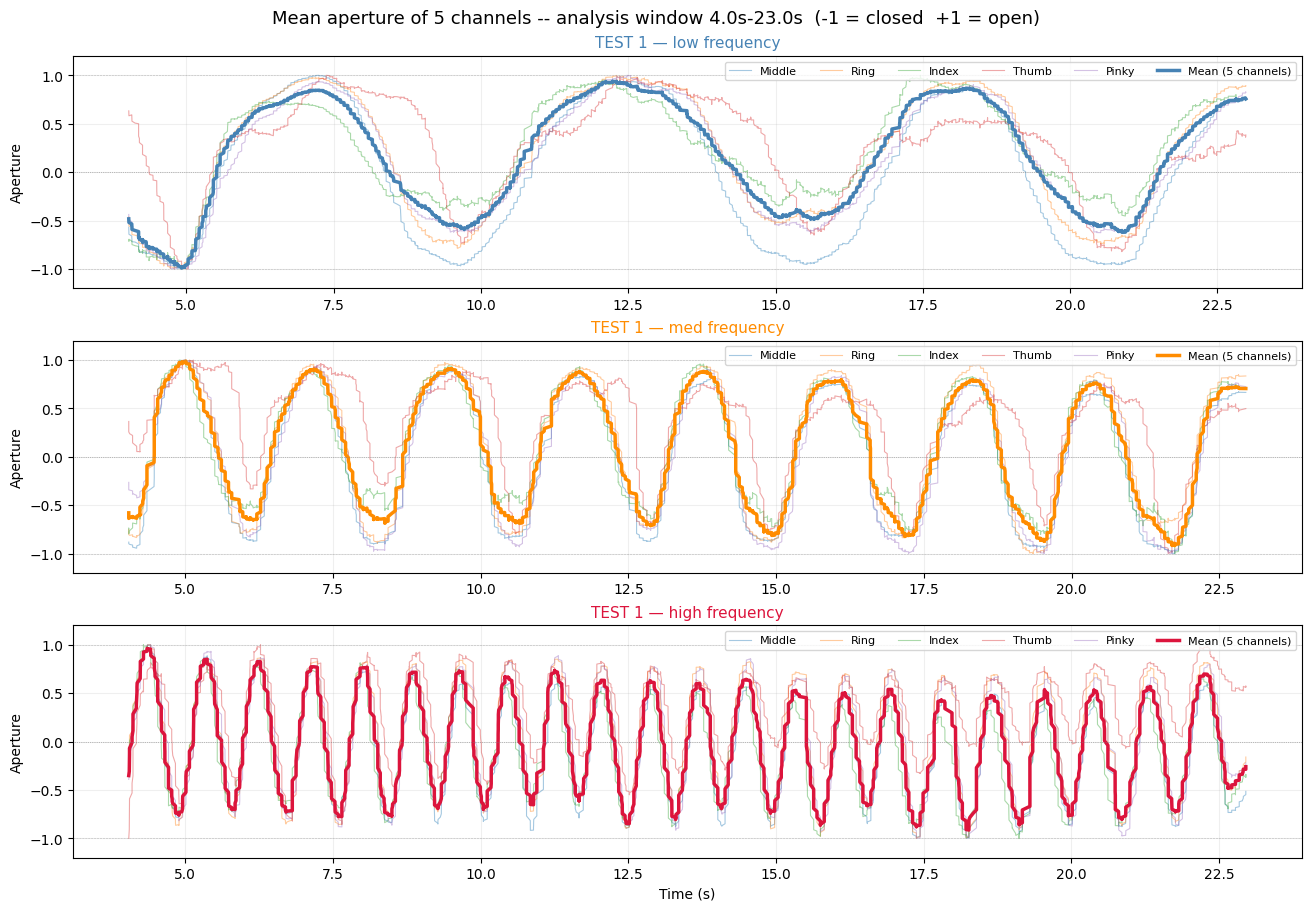

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9),
                         sharey=True, constrained_layout=True)
fig.suptitle(
    f"Mean aperture of 5 channels -- analysis window {T_START}s-{T_END}s"
    "  (-1 = closed  +1 = open)", fontsize=13)

for ax, (label, td) in zip(axes, tests.items()):
    t_w  = td["t"][td["mask"]]
    # Individual channels
    for i, (col, nm) in enumerate(CHANNELS.items()):
        if col not in td["aps"]: continue
        ax.plot(t_w, td["aps"][col][td["mask"]],
                color=COLORS5[i], lw=0.8, alpha=0.4, label=nm)
    # Mean (highlighted)
    ax.plot(t_w, td["mean_ap"][td["mask"]],
            color=TEST1_COLORS[label], lw=2.5, label="Mean (5 channels)")
    ax.axhline( 0, color="gray", lw=0.5, ls=":")
    ax.axhline( 1, color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.axhline(-1, color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.set_ylabel("Aperture")
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f"TEST 1 — {label} frequency", color=TEST1_COLORS[label], fontsize=11)
    ax.legend(ncol=6, fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Time (s)")
plt.savefig("test1_signal.png", bbox_inches="tight")
plt.show()

## TEST 2 — Sequential finger closure (test2_v3)

Protocol: close one finger at a time for 5s, open hand for 2s, move to the next.
Each channel should show exactly **one drop** (closure) during its turn.

In [34]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

TEST2_FILE = "RECORDINGS FOR TEST/test2_v1.csv"
MA_WINDOW2 = 30
T_START2   = 2.0   # adjust if needed
T_END2     = 40.0  # adjust if needed

CHANNELS2 = {
    "Channel_9" : "Thumb",
    "Channel_8" : "Index",
    "Channel_5" : "Middle",
    "Channel_6" : "Ring",
    "Channel_10": "Pinky",
}
CH_COLS2  = list(CHANNELS2.keys())
CH_NAMES2 = list(CHANNELS2.values())
COLORS5   = plt.cm.tab10(range(5))

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0: return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

df2 = pd.read_csv(TEST2_FILE, parse_dates=["Timestamp"])
t2  = (df2["Timestamp"] - df2["Timestamp"].iloc[0]).dt.total_seconds().values

# 1. Moving average on raw data
smoothed2 = {col: moving_average(df2[col].values.astype(float), MA_WINDOW2)
             for col in CH_COLS2 if col in df2.columns}

# 2. Analysis window
mask2 = (t2 >= T_START2) & (t2 <= T_END2)
print(f"{mask2.sum()} samples in window [{T_START2}s, {T_END2}s]")

# 3. Calibration: min/max within window
calib2, aps2 = {}, {}
for col, arr in smoothed2.items():
    arr_w = arr[mask2]
    vmin, vmax = arr_w.min(), arr_w.max()
    calib2[col] = (vmin, vmax)
    aps2[col]   = normalize_linear(arr, vmin, vmax)
    print(f"  {CHANNELS2[col]} ({col}): ADC [{vmin:.0f}, {vmax:.0f}]  "
          f"aperture [{aps2[col][mask2].min():.2f}, {aps2[col][mask2].max():.2f}]")

3798 samples in window [2.0s, 40.0s]
  Thumb (Channel_9): ADC [93507, 123818]  aperture [-1.00, 1.00]
  Index (Channel_8): ADC [225024, 278912]  aperture [-1.00, 1.00]
  Middle (Channel_5): ADC [48912, 66526]  aperture [-1.00, 1.00]
  Ring (Channel_6): ADC [80656, 95473]  aperture [-1.00, 1.00]
  Pinky (Channel_10): ADC [120753, 138418]  aperture [-1.00, 1.00]


### Calibration curves — 5 channels

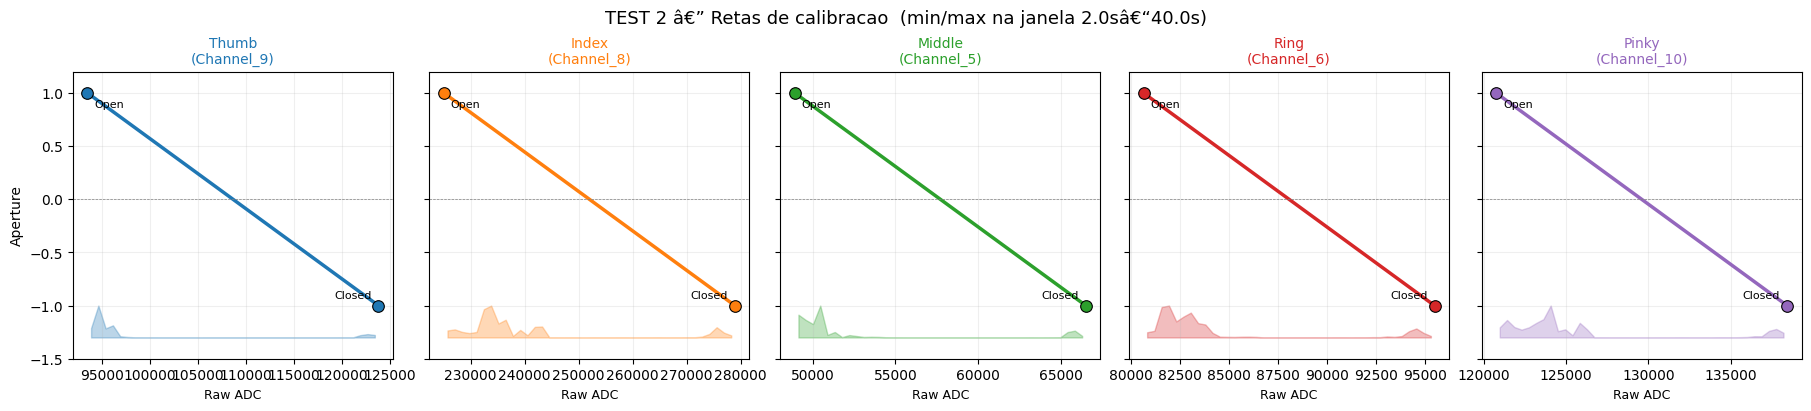

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4),
                         sharey=True, constrained_layout=True)
fig.suptitle(
    f"TEST 2 â€” Retas de calibracao  (min/max na janela {T_START2}sâ€“{T_END2}s)",
    fontsize=13)

for ax, (col, nm), color in zip(axes, CHANNELS2.items(), COLORS5):
    if col not in calib2: ax.set_visible(False); continue
    vmin, vmax = calib2[col]

    v_rng  = np.linspace(vmin, vmax, 200)
    ap_rng = normalize_linear(v_rng, vmin, vmax)
    ax.plot(v_rng, ap_rng, color=color, lw=2.5)

    ax.scatter([vmax, vmin], [-1, 1], color=color,
               s=70, zorder=5, edgecolors="black", lw=0.8)
    ax.annotate("Closed", (vmax, -1), xytext=(-5, 5),
                textcoords="offset points", fontsize=8, ha="right")
    ax.annotate("Open",   (vmin,  1), xytext=(5, -10),
                textcoords="offset points", fontsize=8)

    # Histogram of window data
    raw_w = smoothed2[col][mask2]
    hist, edges = np.histogram(raw_w, bins=40, range=(vmin, vmax))
    hist_norm = hist / hist.max() * 0.3
    ax.fill_between((edges[:-1]+edges[1:])/2, -1.3, -1.3+hist_norm,
                    alpha=0.3, color=color)

    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_title(f"{nm}\n({col})", color=color, fontsize=10)
    ax.set_xlabel("Raw ADC", fontsize=9)
    ax.set_ylim(-1.5, 1.2)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Aperture")
plt.savefig("test2_calibration_curves.png", bbox_inches="tight")
plt.show()

### Aperture per finger — closure sequence

Each subplot shows one channel. You should see **one drop** per channel at the moment
that finger was closed.

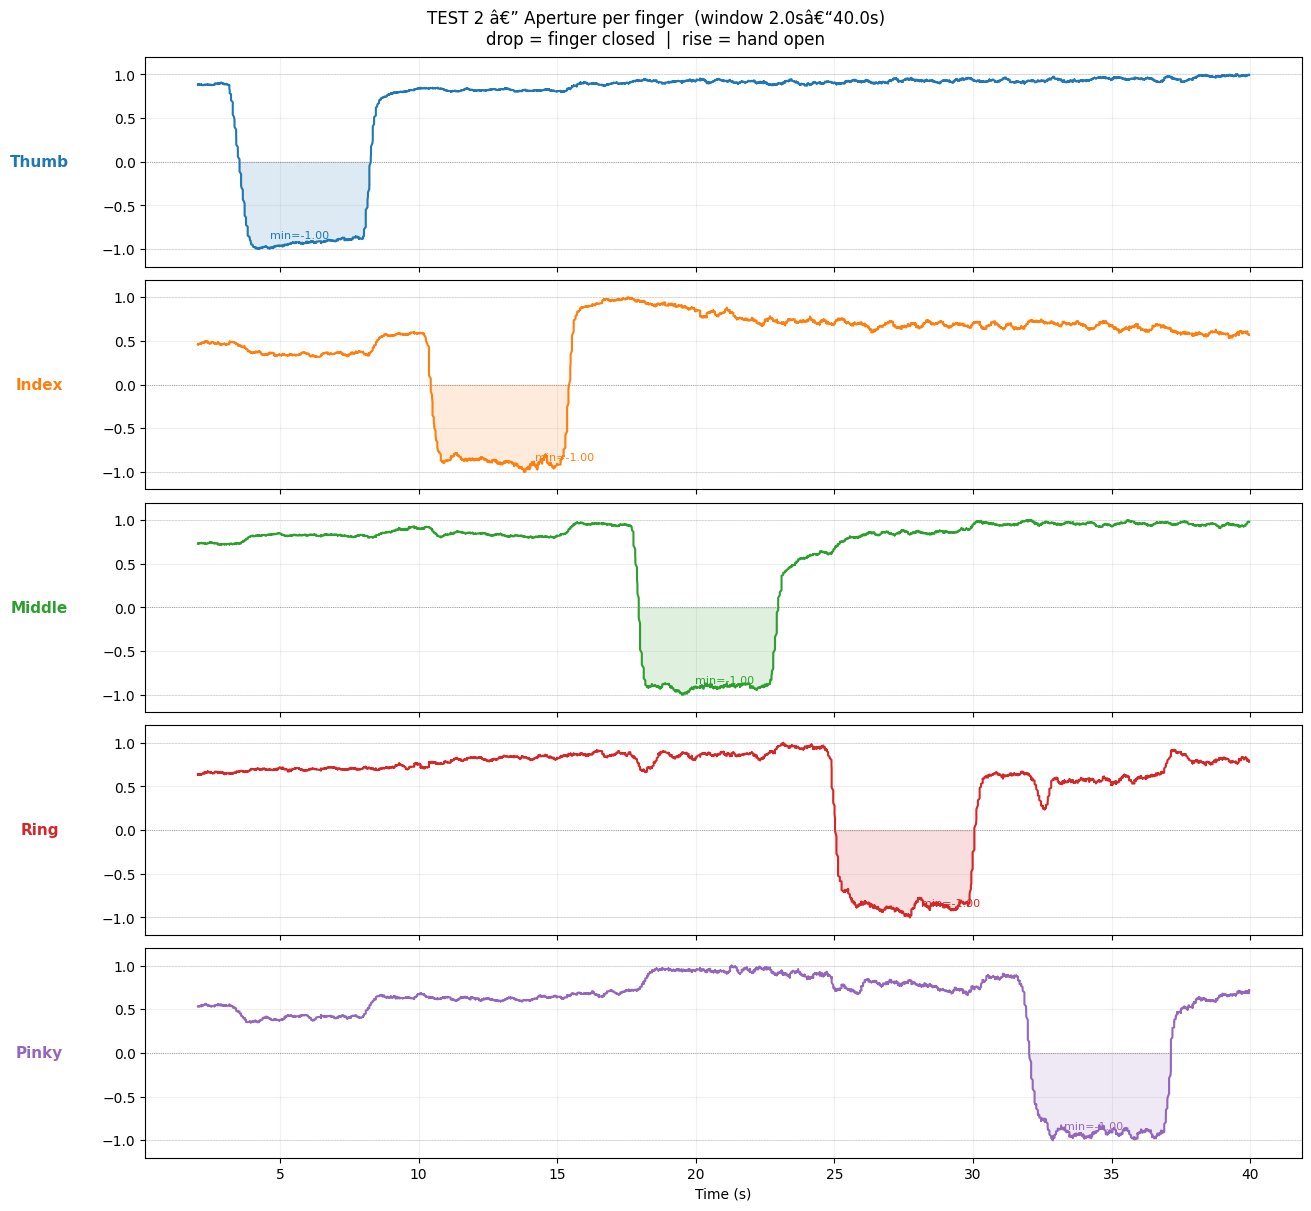

In [36]:
# Anatomical order: Thumb -> Index -> Middle -> Ring -> Pinky
ANAT_ORDER = ["Channel_9", "Channel_8", "Channel_5", "Channel_6", "Channel_10"]

fig, axes = plt.subplots(5, 1, figsize=(13, 12),
                         sharex=True, sharey=True, constrained_layout=True)
fig.suptitle(
    f"TEST 2 â€” Aperture per finger  (window {T_START2}sâ€“{T_END2}s)\n"
    "drop = finger closed  |  rise = hand open",
    fontsize=12)

t2_w = t2[mask2]

for ax, col, color in zip(axes, ANAT_ORDER, COLORS5):
    if col not in aps2: ax.set_visible(False); continue
    nm   = CHANNELS2[col]
    ap_w = aps2[col][mask2]

    ax.plot(t2_w, ap_w, color=color, lw=1.5)
    ax.fill_between(t2_w, ap_w, 0,
                    where=(ap_w < 0), alpha=0.15, color=color,
                    label="closed")
    ax.axhline( 0, color="gray", lw=0.6, ls=":")
    ax.axhline( 1, color="gray", lw=0.4, ls="--", alpha=0.4)
    ax.axhline(-1, color="gray", lw=0.4, ls="--", alpha=0.4)

    # Minimum annotation
    idx_min = np.argmin(ap_w)
    ax.annotate(f"min={ap_w[idx_min]:.2f}",
                xy=(t2_w[idx_min], ap_w[idx_min]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=8, color=color)

    ax.set_ylabel(nm, color=color, fontsize=11, fontweight="bold", rotation=0,
                  labelpad=45, va="center")
    ax.set_ylim(-1.2, 1.2)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Time (s)", fontsize=10)
plt.savefig("test2_signal.png", bbox_inches="tight")
plt.show()

## TEST 6 — Mean of 2 trials (v1 / v2)

Single plot with 2 lines: each line is the mean aperture (5 channels) of one trial.
Min/max calibration computed per file within the analysis window.

v1: [-0.77, 0.97]
v2: [-0.66, 0.90]


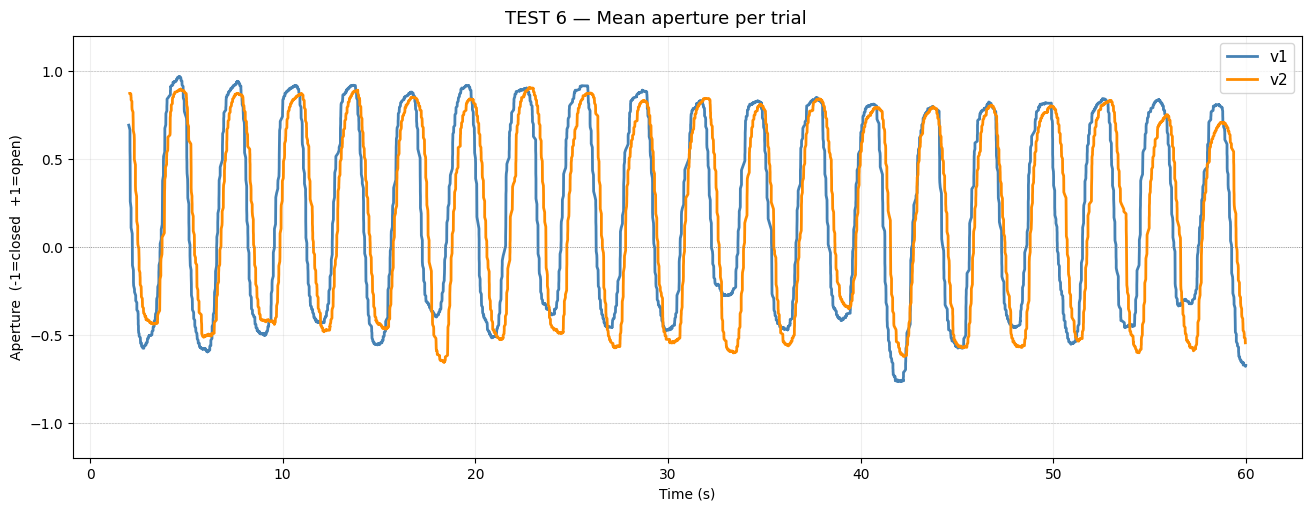

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TEST6_DIR = "RECORDINGS FOR TEST/"
TEST6_FILES = {
    "v1": TEST6_DIR + "teste6-v1.csv",
    "v2": TEST6_DIR + "teste6-v2.csv",
    }
TEST6_COLORS = {"v1": "steelblue", "v2": "darkorange", }

CHANNELS6 = {
    "Channel_5" : "Middle",
    "Channel_6" : "Ring",
    "Channel_8" : "Index",
    "Channel_9" : "Thumb",
    "Channel_10": "Pinky",
}
CH_COLS6 = list(CHANNELS6.keys())

MA_WINDOW6 = 30
T_START6   = 2.0
T_END6     = 60.0

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0:
        return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
fig.suptitle("TEST 6 — Mean aperture per trial", fontsize=13)

for label, path in TEST6_FILES.items():
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    t  = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().values

    smoothed = {col: moving_average(df[col].values.astype(float), MA_WINDOW6)
                for col in CH_COLS6 if col in df.columns}

    t_end = min(T_END6, t[-1])
    mask  = (t >= T_START6) & (t <= t_end)

    calib, aps = {}, {}
    for col, arr in smoothed.items():
        arr_w = arr[mask]
        vmin, vmax = arr_w.min(), arr_w.max()
        calib[col] = (vmin, vmax)
        aps[col]   = normalize_linear(arr, vmin, vmax)

    avail   = [c for c in CH_COLS6 if c in aps]
    arr_all = np.array([aps[c] for c in avail])
    spans   = np.array([calib[c][1] - calib[c][0] for c in avail])
    mean_ap = np.average(arr_all, axis=0, weights=spans)

    t_w    = t[mask]
    mean_w = mean_ap[mask]

    ax.plot(t_w, mean_w, color=TEST6_COLORS[label], lw=2, label=label)
    print(f"{label}: [{mean_w.min():.2f}, {mean_w.max():.2f}]")

ax.axhline(0,  color="gray", lw=0.6, ls=":")
ax.axhline( 1, color="gray", lw=0.4, ls="--", alpha=0.5)
ax.axhline(-1, color="gray", lw=0.4, ls="--", alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Aperture  (-1=closed  +1=open)")
ax.set_ylim(-1.2, 1.2)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.savefig("test6_signal.png", bbox_inches="tight")
plt.show()


c:\Users\carlo\miniforge3\envs\dtu02452\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\carlo\miniforge3\envs\dtu02452\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


v1: drift = -0.018 aperture/min   (start=0.198  end=0.180)
v2: drift = -0.028 aperture/min   (start=0.208  end=0.181)


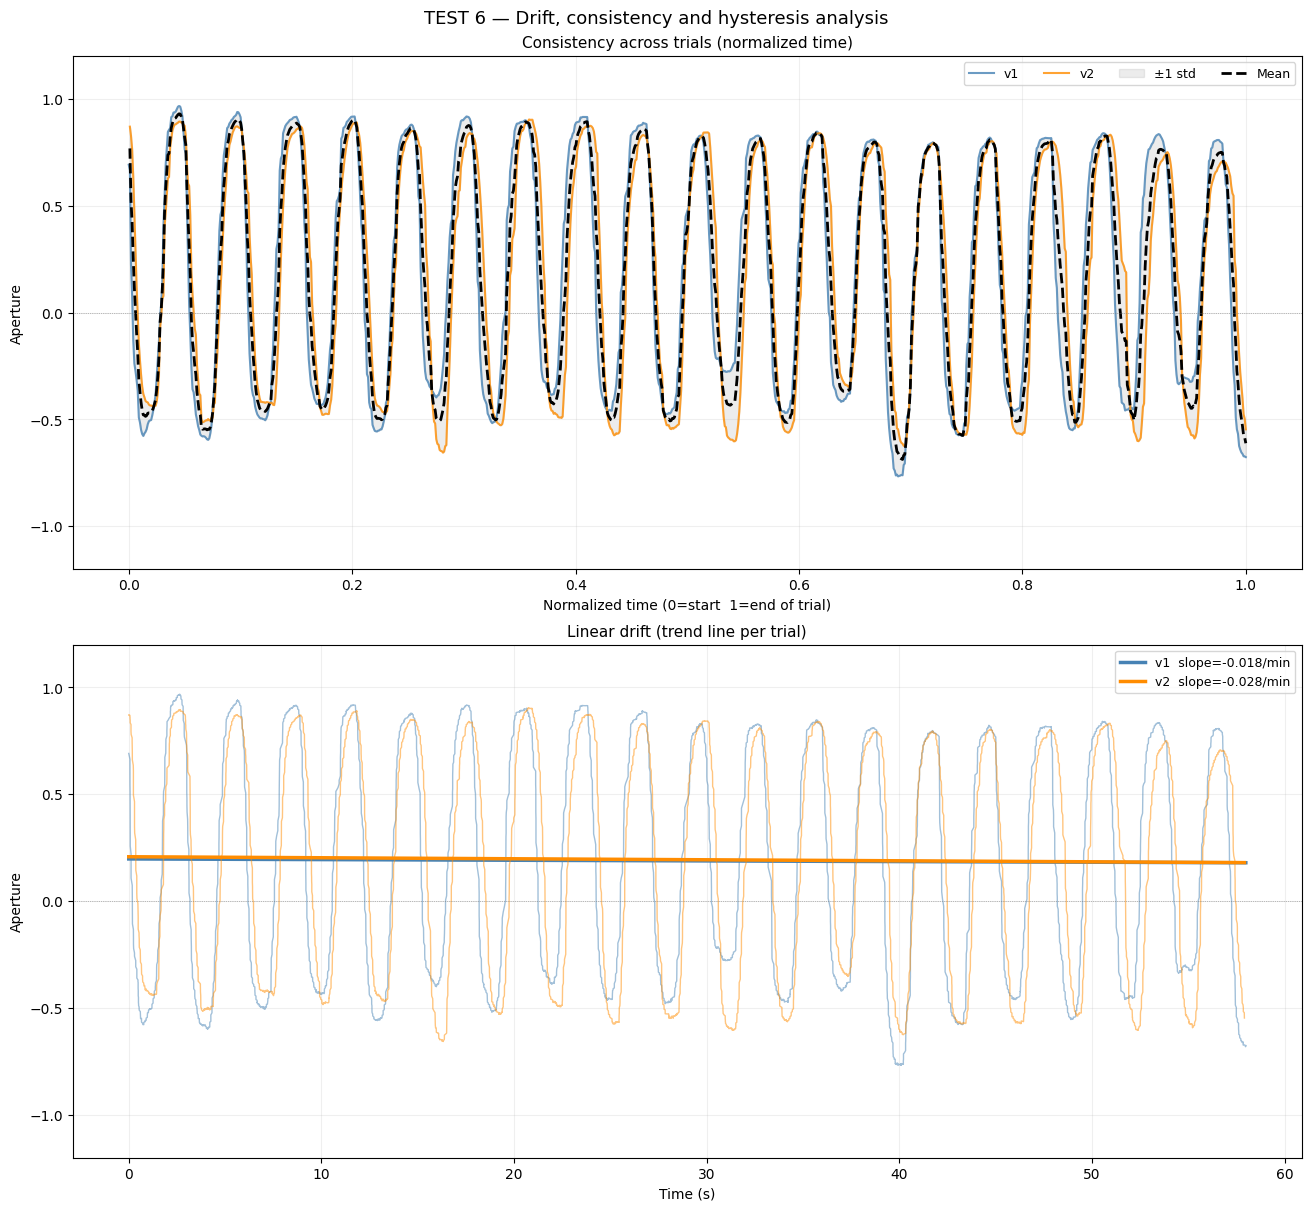

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import detrend

TEST6_DIR = "RECORDINGS FOR TEST/"
TEST6_FILES = {"v1": TEST6_DIR+"teste6-v1.csv",
               "v2": TEST6_DIR+"teste6-v2.csv"}
TEST6_COLORS = {"v1": "steelblue", "v2": "darkorange", }

CHANNELS6 = {"Channel_5":"Middle","Channel_6":"Ring",
             "Channel_8":"Index","Channel_9":"Thumb","Channel_10":"Pinky"}
CH_COLS6 = list(CHANNELS6.keys())
MA_WINDOW6 = 30
T_START6, T_END6 = 2.0, 60.0
N_GRID = 1000  # points on normalized grid [0,1]

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0: return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

# ── load and compute mean aperture per trial ──
trials = {}
for label, path in TEST6_FILES.items():
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    t  = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().values
    smoothed = {col: moving_average(df[col].values.astype(float), MA_WINDOW6)
                for col in CH_COLS6 if col in df.columns}
    t_end = min(T_END6, t[-1])
    mask  = (t >= T_START6) & (t <= t_end)
    calib, aps = {}, {}
    for col, arr in smoothed.items():
        arr_w = arr[mask]
        vmin, vmax = arr_w.min(), arr_w.max()
        calib[col] = (vmin, vmax)
        aps[col]   = normalize_linear(arr, vmin, vmax)
    avail   = [c for c in CH_COLS6 if c in aps]
    arr_all = np.array([aps[c] for c in avail])
    spans   = np.array([calib[c][1]-calib[c][0] for c in avail])
    mean_ap = np.average(arr_all, axis=0, weights=spans)
    trials[label] = dict(t=t[mask]-t[mask][0], ap=mean_ap[mask])

# ── normalized time grid ──
t_norm = np.linspace(0, 1, N_GRID)
interp_trials = {}
for label, td in trials.items():
    t_rel = td["t"] / td["t"][-1]          # normalize to [0,1]
    fn    = interp1d(t_rel, td["ap"], kind="linear", fill_value="extrapolate")
    interp_trials[label] = fn(t_norm)

mat  = np.array(list(interp_trials.values()))   # (3, N_GRID)
mean = mat.mean(axis=0)
std  = mat.std(axis=0)

# ── linear drift per trial ──
drift = {}
for label, td in trials.items():
    t_s  = td["t"]
    ap   = td["ap"]
    coeffs = np.polyfit(t_s, ap, 1)           # [slope, intercept]
    trend  = np.polyval(coeffs, t_s)
    resid  = ap - trend
    drift[label] = dict(t=t_s, ap=ap, trend=trend, resid=resid,
                        slope=coeffs[0], intercept=coeffs[1])
    print(f"{label}: drift = {coeffs[0]*60:+.3f} aperture/min  ",
          f"(start={np.polyval(coeffs,t_s[0]):.3f}  end={np.polyval(coeffs,t_s[-1]):.3f})")

# ── hysteresis: separate ascending vs descending phases ──
def split_hyst(ap, t, sr_approx=100):
    vel = np.gradient(ap, t)
    up  = vel >  0.002
    dn  = vel < -0.002
    return ap[up], ap[dn], vel[up], vel[dn]

# ══ FIGURA ══════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(13, 12), constrained_layout=True)
fig.suptitle("TEST 6 — Drift, consistency and hysteresis analysis", fontsize=13)

# ── Plot 1: consistency across trials (normalized time) ──
ax = axes[0]
for label, y in interp_trials.items():
    ax.plot(t_norm, y, color=TEST6_COLORS[label], lw=1.5, alpha=0.8, label=label)
ax.fill_between(t_norm, mean-std, mean+std, alpha=0.15, color="gray", label="±1 std")
ax.plot(t_norm, mean, color="black", lw=2, ls="--", label="Mean")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Normalized time (0=start  1=end of trial)")
ax.set_ylabel("Aperture")
ax.set_ylim(-1.2, 1.2)
ax.set_title("Consistency across trials (normalized time)", fontsize=11)
ax.legend(fontsize=9, ncol=5)
ax.grid(True, alpha=0.2)

# ── Plot 2: linear drift per trial ──
ax = axes[1]
for label, d in drift.items():
    ax.plot(d["t"], d["ap"], color=TEST6_COLORS[label], lw=1, alpha=0.5)
    ax.plot(d["t"], d["trend"], color=TEST6_COLORS[label], lw=2.5,
            label=f"{label}  slope={d['slope']*60:+.3f}/min")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Aperture")
ax.set_ylim(-1.2, 1.2)
ax.set_title("Linear drift (trend line per trial)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)



plt.savefig("test6_drift_analysis.png", bbox_inches="tight")
plt.show()


## TEST 7 — Inter-individual variability

dragos: [-0.85, 0.98]
Rafaela: [-0.71, 0.92]


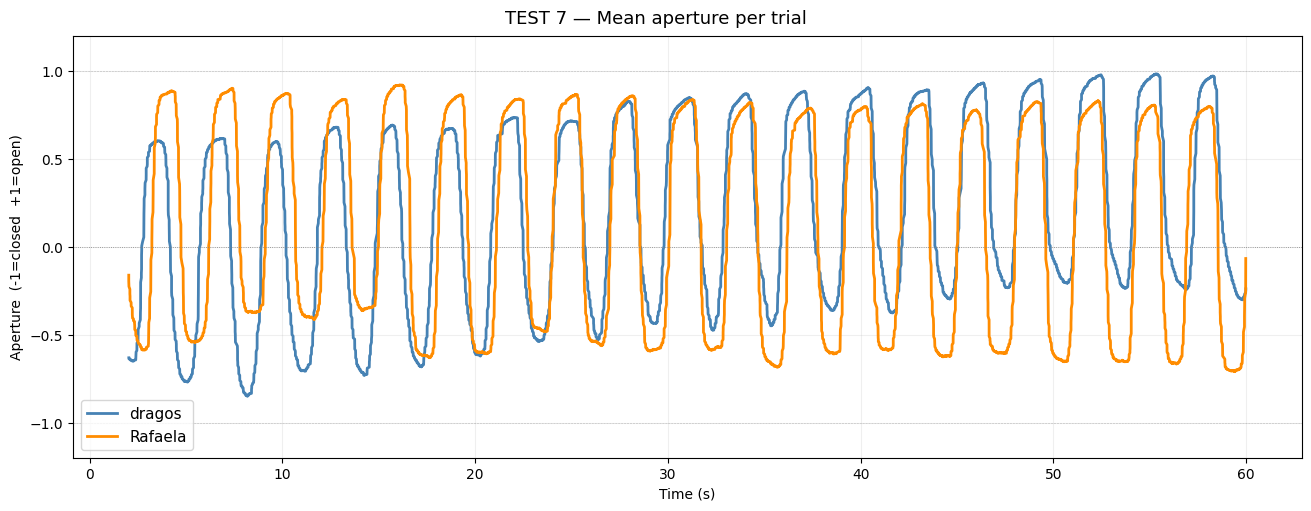

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TEST7_DIR = "RECORDINGS FOR TEST/"
TEST7_FILES = {
    "dragos": TEST7_DIR + "teste7_dragos.csv",
    "Rafaela": TEST7_DIR + "teste7_rafaela.csv",
    }
TEST7_COLORS = {"dragos": "steelblue", "Rafaela": "darkorange", }

CHANNELS7 = {
    "Channel_5" : "Middle",
    "Channel_6" : "Ring",
    "Channel_8" : "Index",
    "Channel_9" : "Thumb",
    "Channel_10": "Pinky",
}
CH_COLS7 = list(CHANNELS7.keys())

MA_WINDOW7 = 30
T_START7   = 2.0
T_END7     = 60.0

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0:
        return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
fig.suptitle("TEST 7 — Mean aperture per trial", fontsize=13)

for label, path in TEST7_FILES.items():
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    t  = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().values

    smoothed = {col: moving_average(df[col].values.astype(float), MA_WINDOW7)
                for col in CH_COLS7 if col in df.columns}

    t_end = min(T_END7, t[-1])
    mask  = (t >= T_START7) & (t <= t_end)

    calib, aps = {}, {}
    for col, arr in smoothed.items():
        arr_w = arr[mask]
        vmin, vmax = arr_w.min(), arr_w.max()
        calib[col] = (vmin, vmax)
        aps[col]   = normalize_linear(arr, vmin, vmax)

    avail   = [c for c in CH_COLS7 if c in aps]
    arr_all = np.array([aps[c] for c in avail])
    spans   = np.array([calib[c][1] - calib[c][0] for c in avail])
    mean_ap = np.average(arr_all, axis=0, weights=spans)

    t_w    = t[mask]
    mean_w = mean_ap[mask]

    ax.plot(t_w, mean_w, color=TEST7_COLORS[label], lw=2, label=label)
    print(f"{label}: [{mean_w.min():.2f}, {mean_w.max():.2f}]")

ax.axhline(0,  color="gray", lw=0.6, ls=":")
ax.axhline( 1, color="gray", lw=0.4, ls="--", alpha=0.5)
ax.axhline(-1, color="gray", lw=0.4, ls="--", alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Aperture  (-1=closed  +1=open)")
ax.set_ylim(-1.2, 1.2)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.savefig("test7_signal.png", bbox_inches="tight")
plt.show()


c:\Users\carlo\miniforge3\envs\dtu02452\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\carlo\miniforge3\envs\dtu02452\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


v1: drift = +0.543 aperture/min   (start=-0.072  end=0.452)
v2: drift = -0.165 aperture/min   (start=0.204  end=0.044)


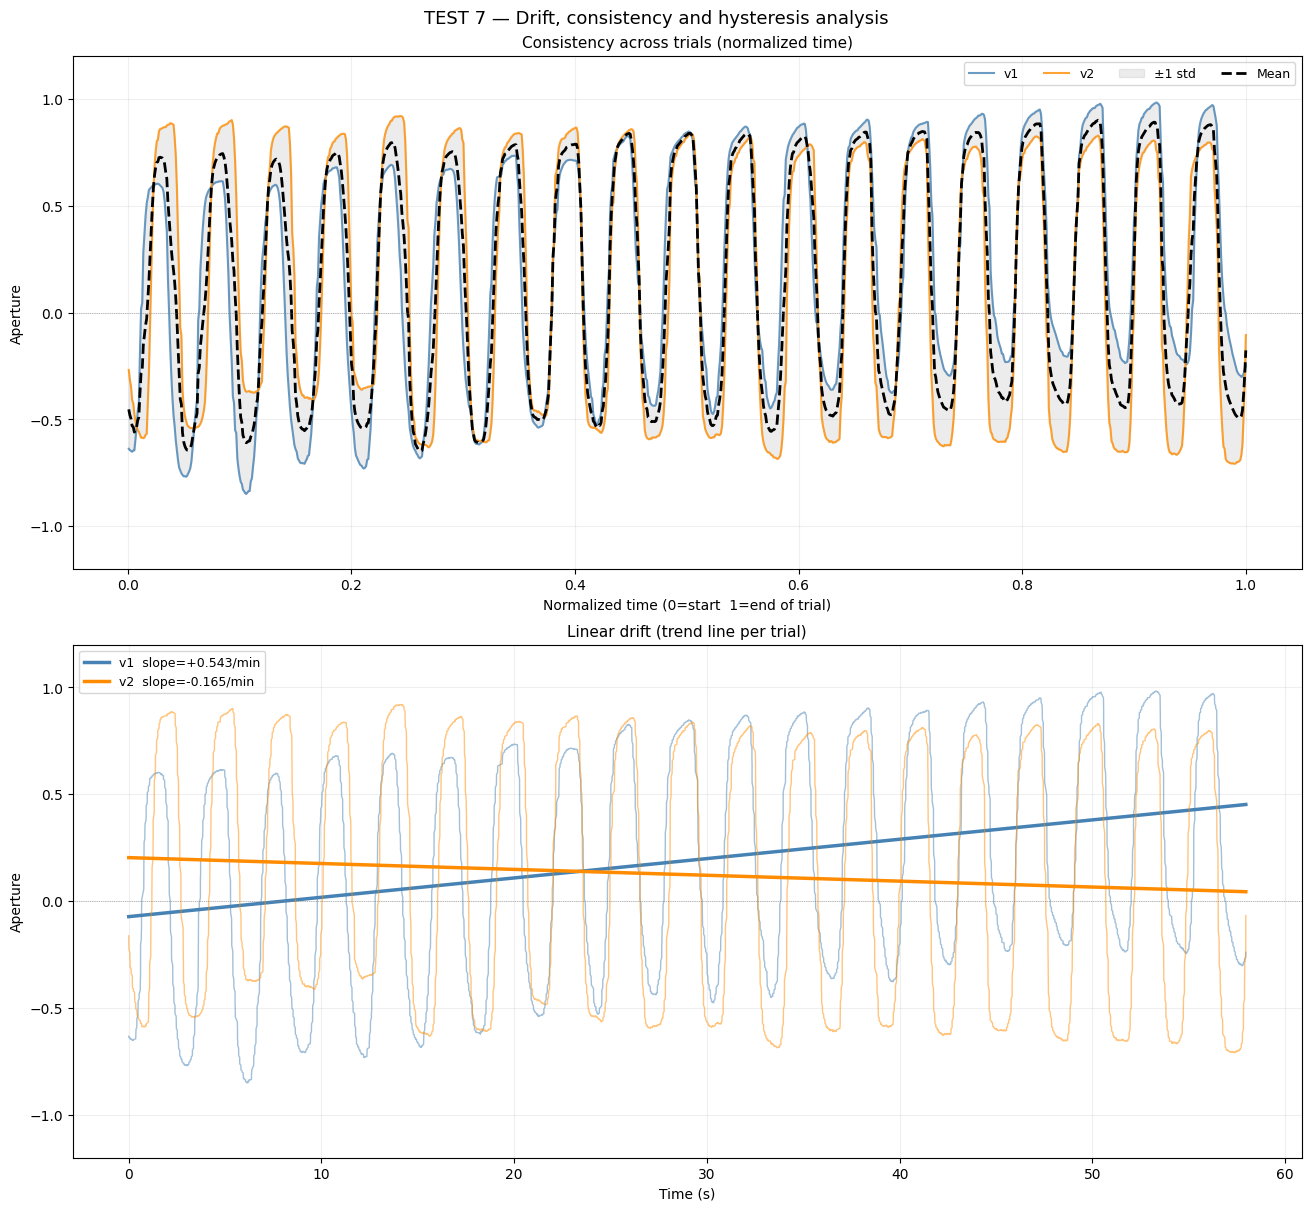

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import detrend

TEST7_DIR = "RECORDINGS FOR TEST/"
TEST7_FILES = {"v1": TEST7_DIR+"teste7_dragos.csv",
               "v2": TEST7_DIR+"teste7_rafaela.csv"}
TEST7_COLORS = {"v1": "steelblue", "v2": "darkorange", }

CHANNELS7 = {"Channel_5":"Middle","Channel_6":"Ring",
             "Channel_8":"Index","Channel_9":"Thumb","Channel_10":"Pinky"}
CH_COLS7 = list(CHANNELS7.keys())
MA_WINDOW7 = 30
T_START7, T_END7 = 2.0, 60.0
N_GRID = 1000  # points on normalized grid [0,1]

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0: return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

# ── load and compute mean aperture per trial ──
trials = {}
for label, path in TEST7_FILES.items():
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    t  = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().values
    smoothed = {col: moving_average(df[col].values.astype(float), MA_WINDOW7)
                for col in CH_COLS7 if col in df.columns}
    t_end = min(T_END7, t[-1])
    mask  = (t >= T_START7) & (t <= t_end)
    calib, aps = {}, {}
    for col, arr in smoothed.items():
        arr_w = arr[mask]
        vmin, vmax = arr_w.min(), arr_w.max()
        calib[col] = (vmin, vmax)
        aps[col]   = normalize_linear(arr, vmin, vmax)
    avail   = [c for c in CH_COLS7 if c in aps]
    arr_all = np.array([aps[c] for c in avail])
    spans   = np.array([calib[c][1]-calib[c][0] for c in avail])
    mean_ap = np.average(arr_all, axis=0, weights=spans)
    trials[label] = dict(t=t[mask]-t[mask][0], ap=mean_ap[mask])

# ── normalized time grid ──
t_norm = np.linspace(0, 1, N_GRID)
interp_trials = {}
for label, td in trials.items():
    t_rel = td["t"] / td["t"][-1]          # normalize to [0,1]
    fn    = interp1d(t_rel, td["ap"], kind="linear", fill_value="extrapolate")
    interp_trials[label] = fn(t_norm)

mat  = np.array(list(interp_trials.values()))   # (3, N_GRID)
mean = mat.mean(axis=0)
std  = mat.std(axis=0)

# ── linear drift per trial ──
drift = {}
for label, td in trials.items():
    t_s  = td["t"]
    ap   = td["ap"]
    coeffs = np.polyfit(t_s, ap, 1)           # [slope, intercept]
    trend  = np.polyval(coeffs, t_s)
    resid  = ap - trend
    drift[label] = dict(t=t_s, ap=ap, trend=trend, resid=resid,
                        slope=coeffs[0], intercept=coeffs[1])
    print(f"{label}: drift = {coeffs[0]*60:+.3f} aperture/min  ",
          f"(start={np.polyval(coeffs,t_s[0]):.3f}  end={np.polyval(coeffs,t_s[-1]):.3f})")

# ── hysteresis: separate ascending vs descending phases ──
def split_hyst(ap, t, sr_approx=100):
    vel = np.gradient(ap, t)
    up  = vel >  0.002
    dn  = vel < -0.002
    return ap[up], ap[dn], vel[up], vel[dn]

# ══ FIGURA ══════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(13, 12), constrained_layout=True)
fig.suptitle("TEST 7 — Drift, consistency and hysteresis analysis", fontsize=13)

# ── Plot 1: consistency across trials (normalized time) ──
ax = axes[0]
for label, y in interp_trials.items():
    ax.plot(t_norm, y, color=TEST7_COLORS[label], lw=1.5, alpha=0.8, label=label)
ax.fill_between(t_norm, mean-std, mean+std, alpha=0.15, color="gray", label="±1 std")
ax.plot(t_norm, mean, color="black", lw=2, ls="--", label="Mean")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Normalized time (0=start  1=end of trial)")
ax.set_ylabel("Aperture")
ax.set_ylim(-1.2, 1.2)
ax.set_title("Consistency across trials (normalized time)", fontsize=11)
ax.legend(fontsize=9, ncol=5)
ax.grid(True, alpha=0.2)

# ── Plot 2: linear drift per trial ──
ax = axes[1]
for label, d in drift.items():
    ax.plot(d["t"], d["ap"], color=TEST7_COLORS[label], lw=1, alpha=0.5)
    ax.plot(d["t"], d["trend"], color=TEST7_COLORS[label], lw=2.5,
            label=f"{label}  slope={d['slope']*60:+.3f}/min")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Aperture")
ax.set_ylim(-1.2, 1.2)
ax.set_title("Linear drift (trend line per trial)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)



plt.savefig("test7_drift_analysis.png", bbox_inches="tight")
plt.show()


## TEST 8 — Tremor detection via IMU (FFT of 3 accelerometer axes)

Objective: detect Parkinson tremors (band **4-8 Hz**) from channels ch15, ch16, ch17.

Pipeline per file:
1. Extract ch15/ch16/ch17 (3 accelerometer axes)
2. Remove DC offset (subtract mean)
3. FFT per axis and sum the power spectra
4. Compute relative power in the 4-8 Hz band and dominant frequency
5. Sliding window detection (20% of total power in band = active tremor)

tremor_250       dom=7.04 Hz  rel=16.1%  pct_time=92.5%
500              dom=5.43 Hz  rel=60.9%  pct_time=100.0%
250_ines         dom=6.89 Hz  rel=29.3%  pct_time=100.0%
500_ines         dom=5.87 Hz  rel=55.6%  pct_time=97.5%
ines             dom=4.20 Hz  rel=24.4%  pct_time=92.5%
1000_ines        dom=4.35 Hz  rel=12.7%  pct_time=32.5%
dedo             dom=7.67 Hz  rel=28.0%  pct_time=60.0%
dedo_250         dom=6.87 Hz  rel=9.4%  pct_time=55.0%
dedo_1000a       dom=7.55 Hz  rel=9.0%  pct_time=25.0%
dedo_1000b       dom=4.29 Hz  rel=12.1%  pct_time=32.5%


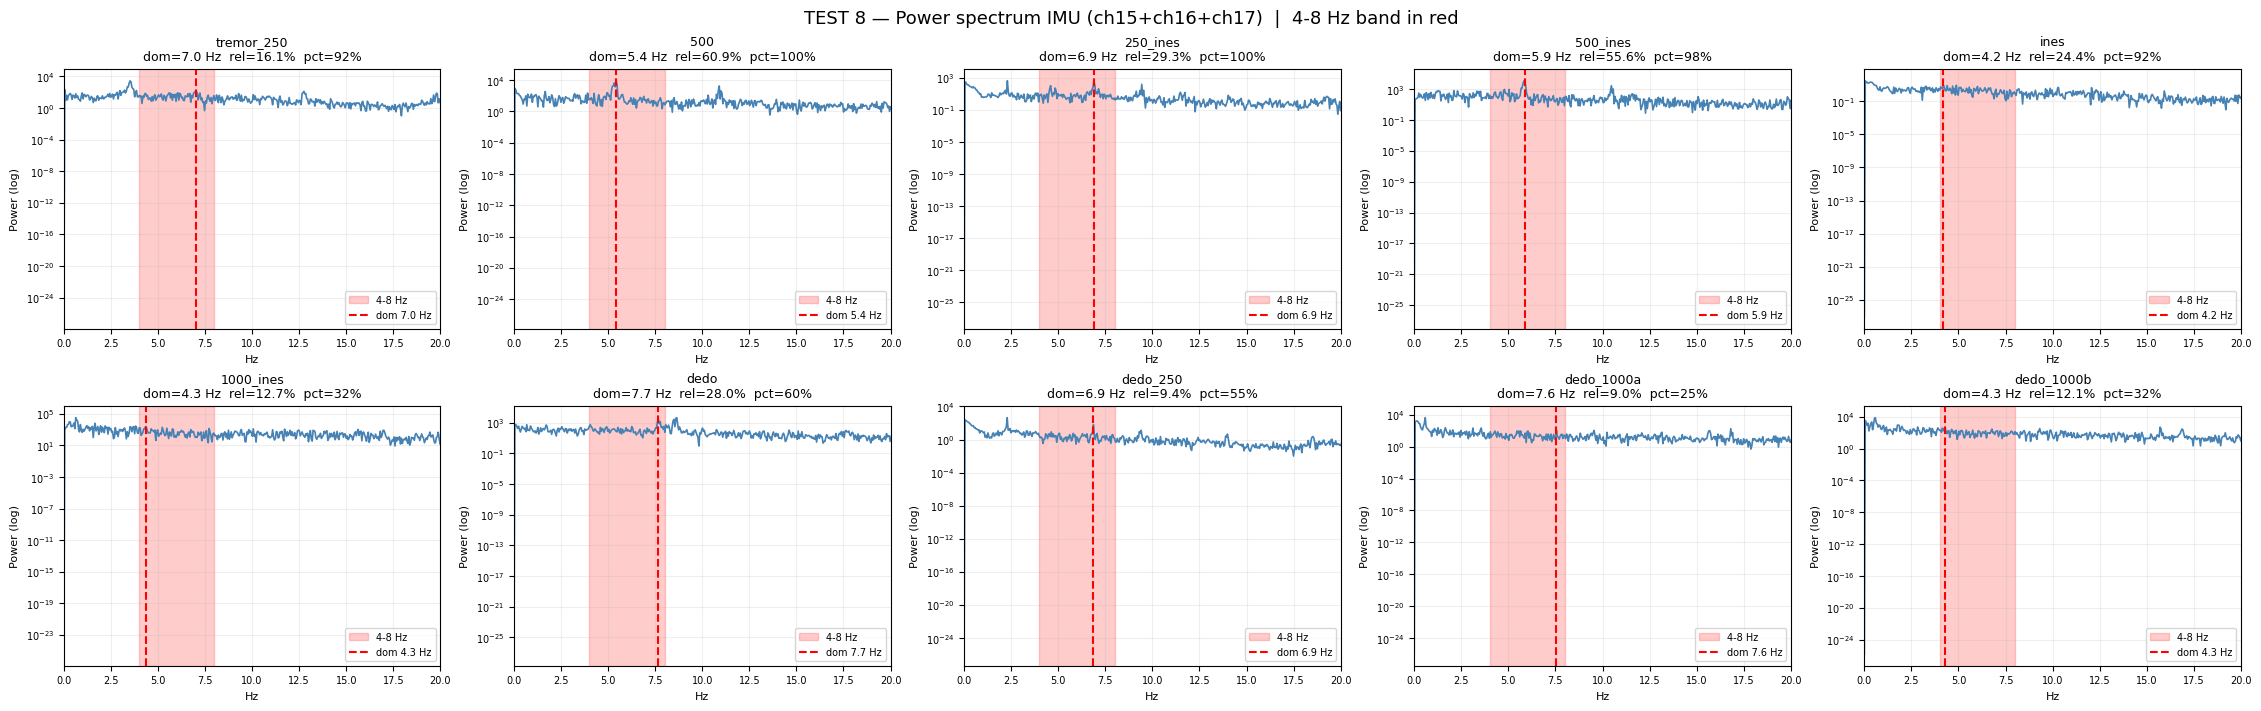

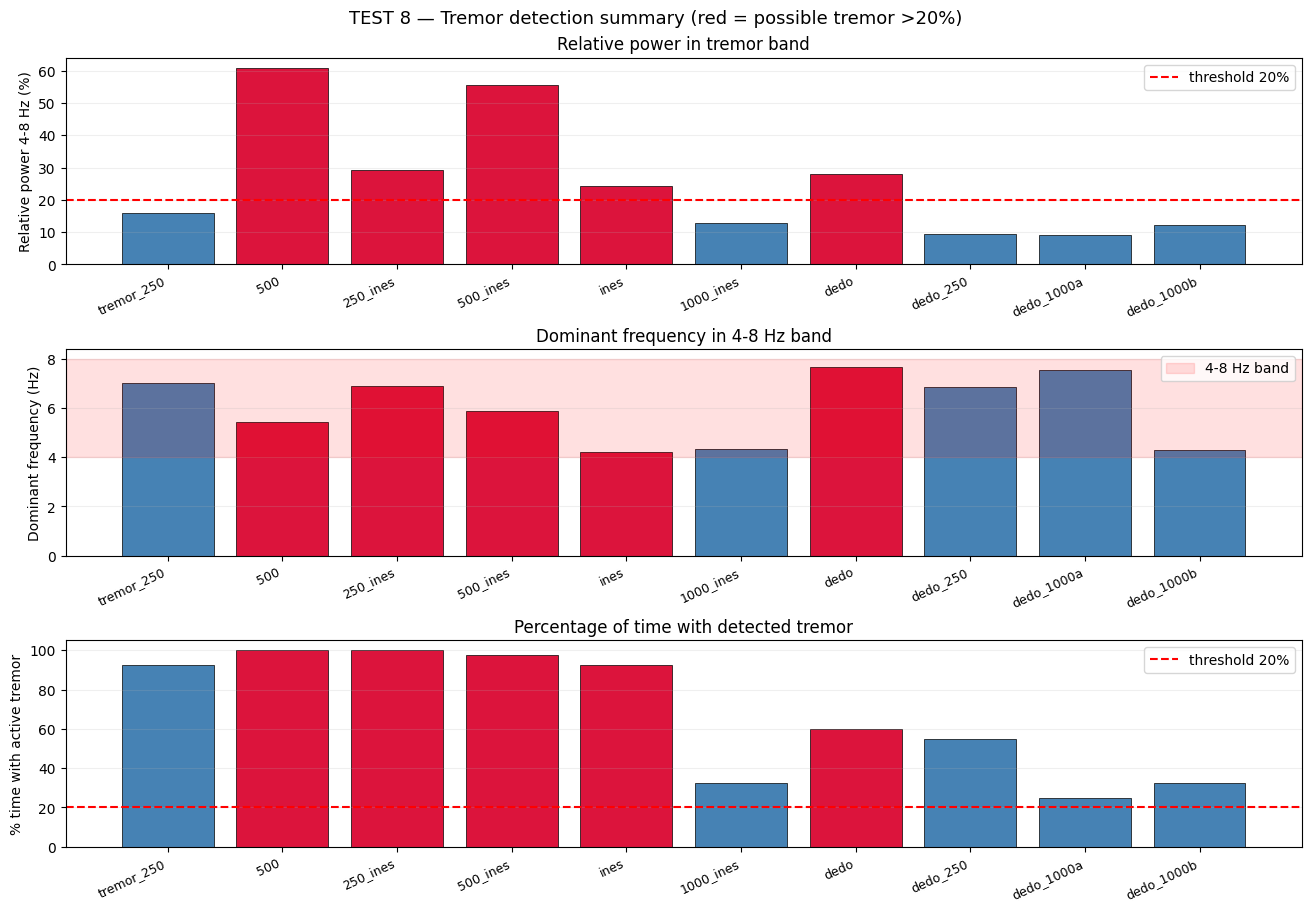

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RECORDINGS_DIR = "recordings/"
TEST8_FILES = {
    "tremor_250" : RECORDINGS_DIR + "test8_tremor_250_levelA_20260619_122154.csv",
    "500"        : RECORDINGS_DIR + "test8_500_levelA_20260619_122451.csv",
    "250_ines"   : RECORDINGS_DIR + "test8_250_ines_levelA_20260619_122834.csv",
    "500_ines"   : RECORDINGS_DIR + "test8_500_ines_levelA_20260619_123045.csv",
    "ines"       : RECORDINGS_DIR + "test8_ines_levelA_20260619_123437.csv",
    "1000_ines"  : RECORDINGS_DIR + "test8_1000_ines_levelA_20260619_123248.csv",
    "dedo"       : RECORDINGS_DIR + "test8_ines_dedo_levelA_20260619_123724.csv",
    "dedo_250"   : RECORDINGS_DIR + "test8_ines_dedo250_levelA_20260619_123945.csv",
    "dedo_1000a" : RECORDINGS_DIR + "test8_ines_dedo1000_levelA_20260619_124216.csv",
    "dedo_1000b" : RECORDINGS_DIR + "test8_ines_dedo1000_levelA_20260619_124331.csv",
}

TREMOR_LOW  = 4.0
TREMOR_HIGH = 8.0
IMU_COLS    = ["ch15", "ch16", "ch17"]

def load_game_csv(path):
    with open(path) as f: lines = f.readlines()
    start = next(i for i, l in enumerate(lines) if l.startswith("time_s"))
    return pd.read_csv(path, skiprows=start)

def tremor_analysis(df):
    arr = df[IMU_COLS].values.astype(float)
    arr -= arr.mean(axis=0)                        # remove DC
    sr  = 1.0 / float(np.median(np.diff(df["time_s"].values)))
    N   = arr.shape[0]

    # FFT and sum of 3 axes
    freqs = np.fft.rfftfreq(N, d=1.0/sr)
    power = np.zeros(len(freqs))
    for ch in range(3):
        power += np.abs(np.fft.rfft(arr[:, ch])) ** 2

    # Tremor band
    band  = (freqs >= TREMOR_LOW) & (freqs <= TREMOR_HIGH)
    bp    = float(power[band].sum())
    rp    = 100.0 * bp / power.sum() if power.sum() > 0 else 0.0
    dom   = float(freqs[band][np.argmax(power[band])]) if band.any() and power[band].max() > 0 else 0.0

    # % time with tremor (sliding window)
    win = max(16, int(sr)); hop = max(1, win // 2)
    wf  = np.fft.rfftfreq(win, d=1.0/sr); wm = (wf >= TREMOR_LOW) & (wf <= TREMOR_HIGH)
    tw = tot = 0
    for s in range(0, N - win + 1, hop):
        seg = arr[s:s+win] - arr[s:s+win].mean(axis=0)
        wp  = np.zeros(len(wf))
        for ch in range(3): wp += np.abs(np.fft.rfft(seg[:, ch])) ** 2
        if wp.sum() > 0 and wp[wm].sum() / wp.sum() > 0.20: tw += 1
        tot += 1
    pct = 100.0 * tw / max(1, tot)

    return dict(freqs=freqs, power=power, band=band,
                band_power=bp, rel_power=rp, dom_hz=dom, pct_time=pct, sr=sr)

# ── load and analyse all files ──
results = {}
for label, path in TEST8_FILES.items():
    df = load_game_csv(path)
    results[label] = tremor_analysis(df)
    print(f"{label:15s}  dom={results[label]['dom_hz']:.2f} Hz  "          f"rel={results[label]['rel_power']:.1f}%  "          f"pct_time={results[label]['pct_time']:.1f}%")

# ══ FIGURA 1: grid de espectros ══════════════════════════════════════
n_files = len(TEST8_FILES)
n_cols  = 5; n_rows = int(np.ceil(n_files / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5*n_cols, 3.5*n_rows),
                         constrained_layout=True)
fig.suptitle("TEST 8 — Power spectrum IMU (ch15+ch16+ch17)  |  4-8 Hz band in red",
             fontsize=13)
flat = axes.flatten()

for ax, (label, res) in zip(flat, results.items()):
    ax.semilogy(res["freqs"], res["power"], color="steelblue", lw=1.2)
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.2, color="red", label="4-8 Hz")
    if res["dom_hz"] > 0:
        ax.axvline(res["dom_hz"], color="red", ls="--", lw=1.5,
                   label=f"dom {res['dom_hz']:.1f} Hz")
    ax.set_xlim(0, 20)
    ax.set_xlabel("Hz", fontsize=8)
    ax.set_ylabel("Power (log)", fontsize=8)
    ax.set_title(
        f"{label}\n"
        f"dom={res['dom_hz']:.1f} Hz  rel={res['rel_power']:.1f}%  pct={res['pct_time']:.0f}%",
        fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

for ax in flat[n_files:]: ax.set_visible(False)
plt.savefig("test8_spectra.png", bbox_inches="tight")
plt.show()

# ══ FIGURA 2: resumo comparativo ═════════════════════════════════════
labels   = list(results.keys())
rel_pows = [results[l]["rel_power"] for l in labels]
dom_hzs  = [results[l]["dom_hz"]    for l in labels]
pct_times= [results[l]["pct_time"]  for l in labels]

x    = np.arange(len(labels))
cols = ["crimson" if r > 20 else "steelblue" for r in rel_pows]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), constrained_layout=True)
fig.suptitle("TEST 8 — Tremor detection summary (red = possible tremor >20%)",
             fontsize=13)

axes[0].bar(x, rel_pows, color=cols, edgecolor="black", lw=0.5)
axes[0].axhline(20, color="red", ls="--", lw=1.5, label="threshold 20%")
axes[0].set_ylabel("Relative power 4-8 Hz (%)")
axes[0].set_title("Relative power in tremor band")
axes[0].legend(); axes[0].grid(True, alpha=0.2, axis="y")

axes[1].bar(x, dom_hzs, color=cols, edgecolor="black", lw=0.5)
axes[1].axhspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.12, color="red", label="4-8 Hz band")
axes[1].set_ylabel("Dominant frequency (Hz)")
axes[1].set_title("Dominant frequency in 4-8 Hz band")
axes[1].legend(); axes[1].grid(True, alpha=0.2, axis="y")

axes[2].bar(x, pct_times, color=cols, edgecolor="black", lw=0.5)
axes[2].axhline(20, color="red", ls="--", lw=1.5, label="threshold 20%")
axes[2].set_ylabel("% time with active tremor")
axes[2].set_title("Percentage of time with detected tremor")
axes[2].legend(); axes[2].grid(True, alpha=0.2, axis="y")

for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=9)

plt.savefig("test8_summary.png", bbox_inches="tight")
plt.show()


### Group "500" - strongest tremor signal:

500 (rel=60.9%, pct=100%) and 500_ines (rel=55.6%, pct=97.5%) -> more than half of all accelerometer energy is in the tremor band throughout the recording. These are the strongest cases.

### Group "ines" and "250_ines" - consistent but weaker tremor:

ines and 250_ines have high pct_time (92-100%) but lower rel (24-29%) -> tremor is always present but does not dominate the spectrum as strongly.

### Group "1000_ines" - weak detection:

rel=12.7%, pct=32.5% -> the tremor band signal is weak and only appears 1/3 of the time.

### Group "dedo" - finger movements:

Low rel (9-28%), variable pct_time (25-60%) -> finger movements produce less energy in this band; the detector is less confident.

tremor_250 - curious case: pct_time=92.5% (almost always detected) but rel=16.1% (low relative energy). Tremor is always present but weak relative to the rest of the movement.

## Relative power (rel%)
FFT decomposes the signal into all frequencies from 0 Hz up to ~29 Hz (half of 58.8 Hz). Relative power is:

rel = energy in 4-8 Hz band / total energy x 100

If rel=60.9% (case 500) -> more than half of all accelerometer movement is happening between 4-8 Hz. If rel=9% (dedo_250) -> almost all energy is at other frequencies.

## 20% threshold
This value is inherited from the game code - semi-arbitrary. It means: "if in a ~1s window the 4-8 Hz band has more than 20% of total energy, classify as active tremor." It could be changed to 30% or 15% depending on what makes more clinical sense. It has no strict scientific basis.

## Bars in the second plot (dominant frequency)
The bars show the Hz value of the most energetic frequency within the 4-8 Hz band. For example, a bar at 5.43 Hz does not mean the signal goes from 0 to 5.43 Hz - it means that within the 4-8 Hz window, the power peak is at 5.43 Hz. It is the position of the peak, not the amplitude.

## % time with tremor
The 20s signal is divided into ~1s windows with overlap. For each window rel% is computed. If rel% > 20%, that window counts as active tremor. The result is how many windows passed the threshold as a percentage. pct=100% = tremor detected in all windows.

tremor_250       global_peak=3.52 Hz  band_peak_4-8Hz=7.04 Hz  rel=16.1%
500              global_peak=5.43 Hz  band_peak_4-8Hz=5.43 Hz  rel=60.9%
250_ines         global_peak=2.30 Hz  band_peak_4-8Hz=6.89 Hz  rel=29.3%
500_ines         global_peak=5.87 Hz  band_peak_4-8Hz=5.87 Hz  rel=55.6%
ines             global_peak=0.05 Hz  band_peak_4-8Hz=4.20 Hz  rel=24.4%
1000_ines        global_peak=0.64 Hz  band_peak_4-8Hz=4.35 Hz  rel=12.7%
dedo             global_peak=8.65 Hz  band_peak_4-8Hz=7.67 Hz  rel=28.0%
dedo_250         global_peak=2.29 Hz  band_peak_4-8Hz=6.87 Hz  rel=9.4%
dedo_1000a       global_peak=0.58 Hz  band_peak_4-8Hz=7.55 Hz  rel=9.0%
dedo_1000b       global_peak=0.59 Hz  band_peak_4-8Hz=4.29 Hz  rel=12.1%


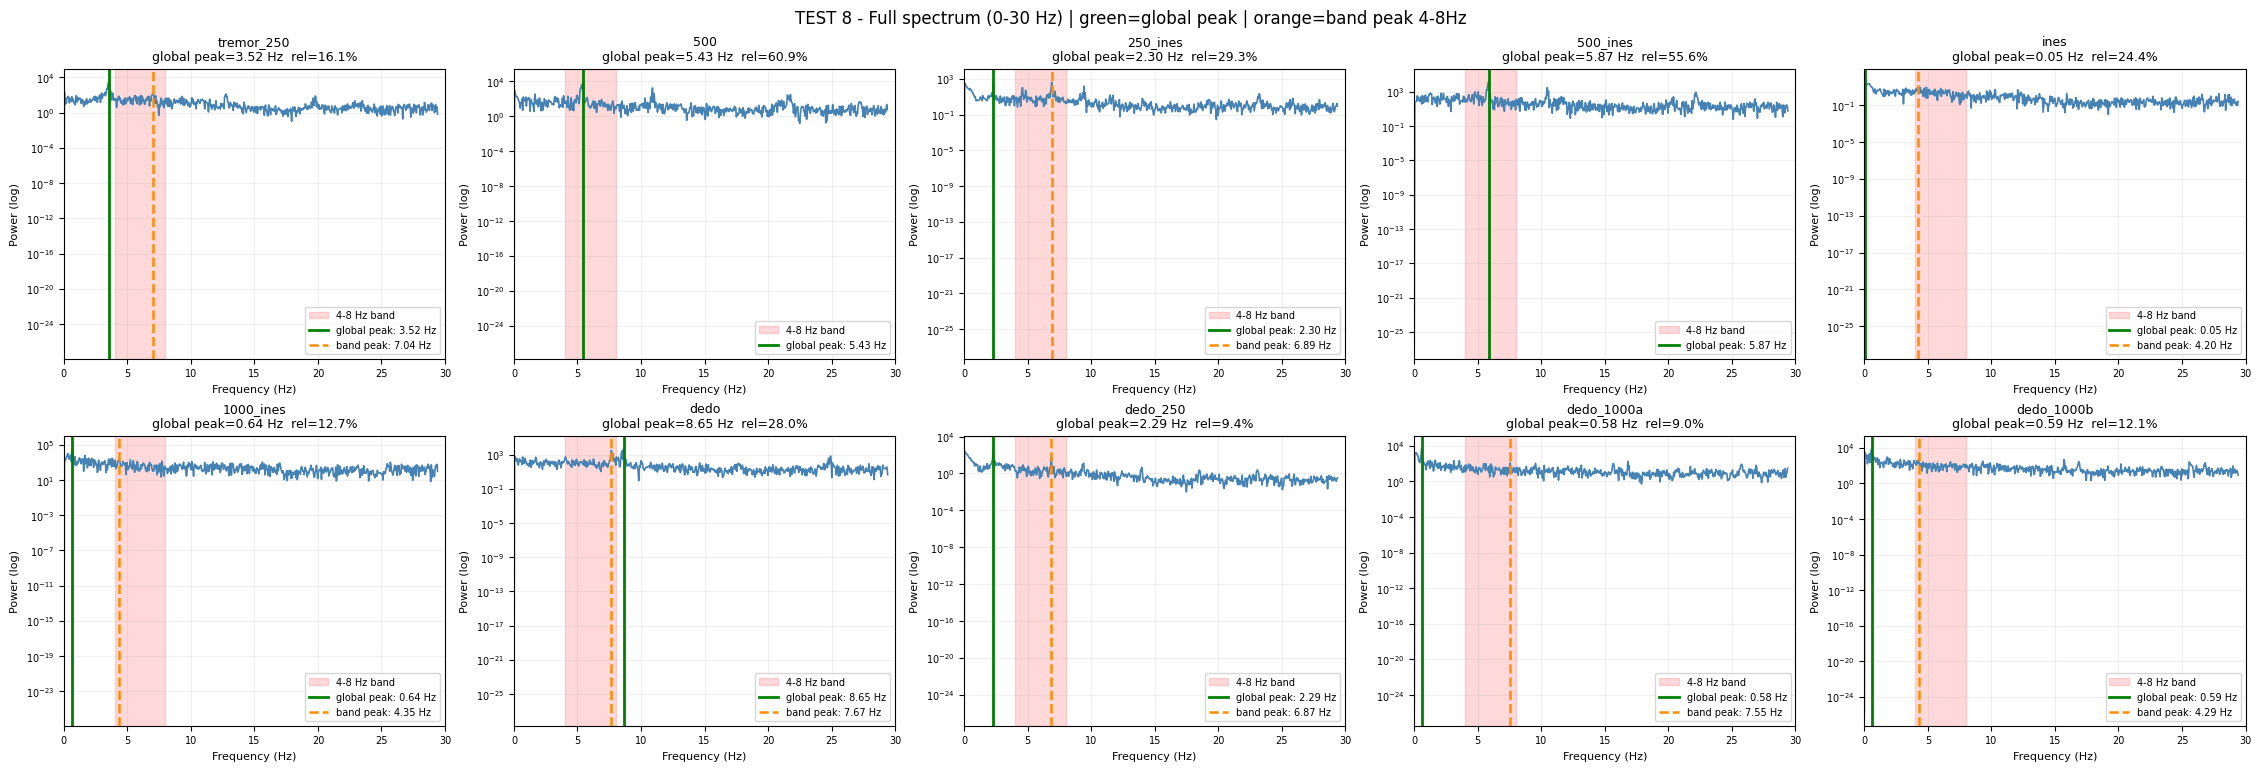

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RECORDINGS_DIR = "recordings/"
TEST8_FILES = {
    "tremor_250" : RECORDINGS_DIR + "test8_tremor_250_levelA_20260619_122154.csv",
    "500"        : RECORDINGS_DIR + "test8_500_levelA_20260619_122451.csv",
    "250_ines"   : RECORDINGS_DIR + "test8_250_ines_levelA_20260619_122834.csv",
    "500_ines"   : RECORDINGS_DIR + "test8_500_ines_levelA_20260619_123045.csv",
    "ines"       : RECORDINGS_DIR + "test8_ines_levelA_20260619_123437.csv",
    "1000_ines"  : RECORDINGS_DIR + "test8_1000_ines_levelA_20260619_123248.csv",
    "dedo"       : RECORDINGS_DIR + "test8_ines_dedo_levelA_20260619_123724.csv",
    "dedo_250"   : RECORDINGS_DIR + "test8_ines_dedo250_levelA_20260619_123945.csv",
    "dedo_1000a" : RECORDINGS_DIR + "test8_ines_dedo1000_levelA_20260619_124216.csv",
    "dedo_1000b" : RECORDINGS_DIR + "test8_ines_dedo1000_levelA_20260619_124331.csv",
}
TREMOR_LOW, TREMOR_HIGH = 4.0, 8.0
IMU_COLS = ["ch15", "ch16", "ch17"]

def load_game_csv(path):
    with open(path) as f: lines = f.readlines()
    start = next(i for i, l in enumerate(lines) if l.startswith("time_s"))
    return pd.read_csv(path, skiprows=start)

spectra = {}
for label, path in TEST8_FILES.items():
    df  = load_game_csv(path)
    arr = df[IMU_COLS].values.astype(float)
    arr -= arr.mean(axis=0)
    sr  = 1.0 / float(np.median(np.diff(df["time_s"].values)))
    N   = arr.shape[0]
    freqs = np.fft.rfftfreq(N, d=1.0/sr)
    power = np.zeros(len(freqs))
    for ch in range(3):
        power += np.abs(np.fft.rfft(arr[:, ch])) ** 2

    global_peak_hz = float(freqs[np.argmax(power)])
    band = (freqs >= TREMOR_LOW) & (freqs <= TREMOR_HIGH)
    band_peak_hz   = float(freqs[band][np.argmax(power[band])]) if band.any() else 0.0
    rel_power      = 100.0 * power[band].sum() / power.sum() if power.sum() > 0 else 0.0

    spectra[label] = dict(freqs=freqs, power=power,
                          global_peak=global_peak_hz,
                          band_peak=band_peak_hz,
                          rel_power=rel_power)
    print(f"{label:15s}  global_peak={global_peak_hz:.2f} Hz  band_peak_4-8Hz={band_peak_hz:.2f} Hz  rel={rel_power:.1f}%")

# grid de espectros completos
n_cols = 5; n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5*n_cols, 3.8*n_rows),
                         constrained_layout=True)
fig.suptitle(
    "TEST 8 - Full spectrum (0-30 Hz) | green=global peak | orange=band peak 4-8Hz",
    fontsize=12)

for ax, (label, res) in zip(axes.flatten(), spectra.items()):
    f, p = res["freqs"], res["power"]
    ax.semilogy(f, p, color="steelblue", lw=1.2, zorder=2)
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.15, color="red", label="4-8 Hz band")
    ax.axvline(res["global_peak"], color="green", lw=2, ls="-",
               label=f"global peak: {res['global_peak']:.2f} Hz")
    if abs(res["band_peak"] - res["global_peak"]) > 0.1:
        ax.axvline(res["band_peak"], color="darkorange", lw=1.8, ls="--",
                   label=f"band peak: {res['band_peak']:.2f} Hz")
    ax.set_xlim(0, 30)
    ax.set_xlabel("Frequency (Hz)", fontsize=8)
    ax.set_ylabel("Power (log)", fontsize=8)
    ax.set_title(
        f"{label}\n"
        f"global peak={res['global_peak']:.2f} Hz  rel={res['rel_power']:.1f}%",
        fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

plt.savefig("test8_full_spectra.png", bbox_inches="tight")
plt.show()


### Case A - global peak INSIDE the band (green coincides with red zone)

global peak = 5.4 Hz -> the movement itself is in the tremor band

This means the detector is capturing the movement itself, not pathological tremor. The energy in the band is high simply because the person moves at that frequency.

### Case B - global peak OUTSIDE the band (green outside, orange inside)

global peak = 12 Hz -> movement at 12 Hz, but "tremor" detected at 6 Hz

The detector is capturing noise, harmonics or spectral leakage from the real peak. Detection is less reliable.

## RESULTS

### Group 1 — Movement INSIDE the band (global peak = 4-8 Hz peak)

500 GP:5.43 Hz REL:60.9%

500_ines GP:5.87 Hz REL:55.6%

The movement itself is at 5-6 Hz. The detector captures very high energy but it is NOT tremor - it is the hand movement itself. Impossible to separate the two.

### Group 2 — Harmonics (global peak below the band)

tremor_250 GP: 3.52 Hz BAND PEAK: 7.04 Hz -> 3.52 x 2 = 7.04

250_ines GP: 2.30 Hz BAND PEAK: 6.89 Hz -> 2.30 x 3 = 6.90

dedo_250 GP: 2.29 Hz BAND PEAK: 6.87 Hz -> 2.29 x 3 = 6.87

The detected "tremor" is the 2nd or 3rd harmonic of the main movement. Not real tremor - a mathematical consequence of FFT when the signal has a non-sinusoidal shape.

### Group 3 — Very slow movement (quasi-static)

- ines
- 1000_ines
- dedo_1000a
- dedo_1000b

The main movement is nearly DC. Energy in 4-8 Hz does not come from movement - it is real physiological hand vibration. These are the most trustworthy cases for tremor detection.

## TEST 9 — Game analysis with 3 hand range-of-motion levels

3 CSV files, each playing the same game but with different hand closure capacity:
- **100**: closes hand completely
- **50**: closes only halfway
- **20**: barely closes

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TEST9_DIR = "RECORDINGS FOR TEST/"
TEST9_FILES = {
    "100": TEST9_DIR + "test9_100_levelB.csv",
    "50" : TEST9_DIR + "test9_50_levelB.csv",
    "20" : TEST9_DIR + "test9_20_levelB.csv",
}
TEST9_COLORS = {"100": "steelblue", "50": "darkorange", "20": "crimson"}

FINGER_COLS = ["Thumb", "Index", "Middle", "Ring", "Pinky"]
COLORS5     = plt.cm.tab10(range(5))
MA_WINDOW   = 5    # light smoothing (data already normalized by game)
T_START     = 2.0
T_END       = 60.0

def load_game_csv(path):
    """Read game CSV: skip calibration header, return df and spans."""
    spans = None
    with open(path) as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("calib_span"):
            vals = [x.strip() for x in line.split(",")[1:]]
            spans = np.array([float(v) for v in vals if v.replace(".","").replace("-","").isdigit() or (v and v[0].isdigit())])
            break
    start = next(i for i, l in enumerate(lines) if l.startswith("time_s"))
    df = pd.read_csv(path, skiprows=start)
    return df, spans

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

tests9 = {}
for label, path in TEST9_FILES.items():
    df, spans = load_game_csv(path)
    t = df["time_s"].values

    avail = [c for c in FINGER_COLS if c in df.columns]

    # light smoothing
    smoothed = {c: moving_average(df[c].values.astype(float), MA_WINDOW) for c in avail}

    t_end = min(T_END, t[-1])
    mask  = (t >= T_START) & (t <= t_end)
    print(f"{label}: {mask.sum()} samples in window [{T_START}s, {t_end:.0f}s]")

    # use calibration spans as weights (stored in file header)
    arr_all = np.array([smoothed[c] for c in avail])
    w = spans[:len(avail)] if spans is not None and len(spans) >= len(avail) else np.ones(len(avail))
    w = np.maximum(w, 1.0)   # ensure no weight is zero
    mean_ap = np.average(arr_all, axis=0, weights=w)

    tests9[label] = dict(t=t, mask=mask, smoothed=smoothed, mean_ap=mean_ap)
    ap_w = mean_ap[mask]
    print(f"  aperture in window [{ap_w.min():.2f}, {ap_w.max():.2f}]")
    for c in avail:
        w_vals = smoothed[c][mask]
        print(f"    {c}: [{w_vals.min():.2f}, {w_vals.max():.2f}]")
    print()


100: 1677 samples in window [2.0s, 30s]
  aperture in window [-0.74, 0.93]
    Thumb: [-1.00, 0.96]
    Index: [-0.61, 0.92]
    Middle: [-0.47, 1.00]
    Ring: [-0.87, 0.96]
    Pinky: [-1.00, 0.88]

50: 1681 samples in window [2.0s, 30s]
  aperture in window [-0.76, 0.90]
    Thumb: [-1.00, 1.00]
    Index: [-0.72, 0.94]
    Middle: [-1.00, 1.00]
    Ring: [-0.82, 1.00]
    Pinky: [-1.00, 0.71]

20: 1687 samples in window [2.0s, 30s]
  aperture in window [-0.90, 0.93]
    Thumb: [-1.00, 1.00]
    Index: [-1.00, 0.87]
    Middle: [-1.00, 1.00]
    Ring: [-1.00, 1.00]
    Pinky: [-1.00, 1.00]



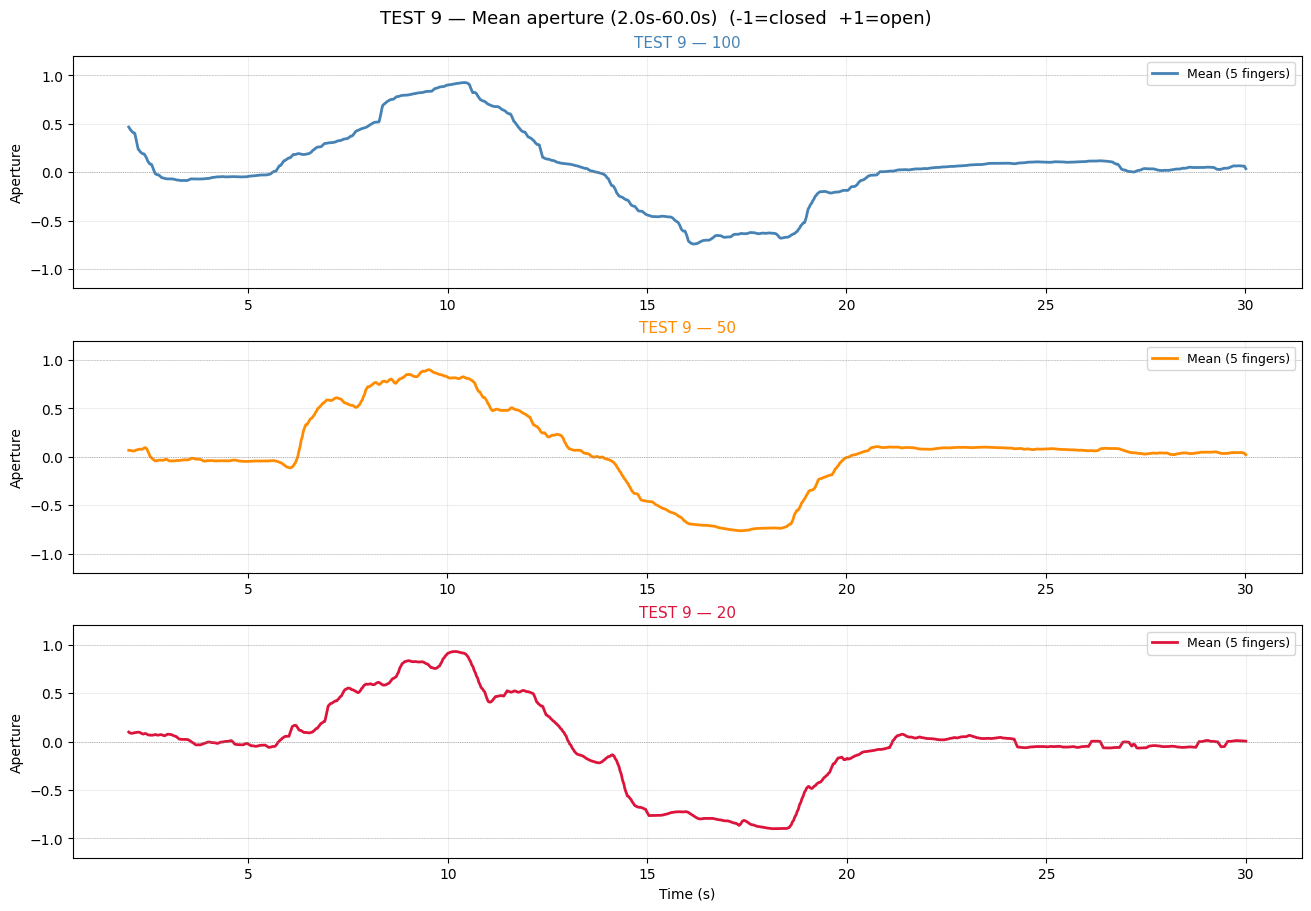

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9),
                         sharey=True, constrained_layout=True)
fig.suptitle(
    f"TEST 9 — Mean aperture ({T_START}s-{T_END}s)  (-1=closed  +1=open)",
    fontsize=13)

for ax, (label, td) in zip(axes, tests9.items()):
    t_w = td["t"][td["mask"]]

    ax.plot(t_w, td["mean_ap"][td["mask"]],
            color=TEST9_COLORS[label], lw=2, label="Mean (5 fingers)")
    ax.axhline( 0, color="gray", lw=0.5, ls=":")
    ax.axhline( 1, color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.axhline(-1, color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.set_ylabel("Aperture")
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f"TEST 9 — {label}", color=TEST9_COLORS[label], fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Time (s)")
plt.savefig("test9_signal.png", bbox_inches="tight")
plt.show()
